In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from itertools import chain
from tqdm import tqdm
from pathlib import Path
from protein_search_evals.datasets.pfam import PfamDataset
from protein_search_evals.datasets.pfam import Pfam20Dataset
from protein_search_evals.datasets.pfam import PfamSubsetDataset

In [33]:
def plot_histogram(
    counts: list[int],
    xlabel: str,
) -> None:
    # Plot settings for high-quality publication
    plt.style.use('seaborn-v0_8-paper')  # Use a clean style
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
    })
    
    # Create the histogram
    fig, ax = plt.subplots(figsize=(8, 6))  # Specify figure size for better resolution
    
    bins = np.logspace(0.1, np.log10(max(counts)), 50)  # Log-spaced bins for log-scale histogram
    ax.hist(counts, bins=bins, color='steelblue', edgecolor='black', alpha=0.7, log=True)
    
    # Customize the plot
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
    
    # Tight layout to avoid clipping
    plt.tight_layout()
    
    # Save as high-resolution image for publication
    #plt.savefig("pfam_sequence_distribution.png", dpi=300)
    
    # Show the plot
    plt.show()

def plot_line_chart(
    x: list[float],
    y: list[float],
    xlabel: str,
    ylabel: str,
    title: str = "",
    save_path: str | None = None
) -> None:
    """Plot a line chart.

    Parameters
    ----------
    x : list[float]
        Data for the x-axis.
    y : list[float]
        Data for the y-axis.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    title : str, optional
        Title of the plot, by default "" (no title).
    save_path : str | None, optional
        If provided, saves the figure to the given path, by default None.
    
    Returns
    -------
    None
    """
    # High-quality publication settings
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
    })

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the line chart
    ax.plot(x, y, marker='o', linestyle='-', color='steelblue', markersize=5)

    # Customize the plot
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    #ax.legend()
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    # Optimize layout
    plt.tight_layout()

    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # Show the plot
    plt.show()

# Plot the length distribution of the original Pfam

In [19]:
dataset = PfamDataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')

In [20]:
families = dataset.load_families()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json


In [21]:
sequences_per_family = [len(value) for key, value in families.items()]

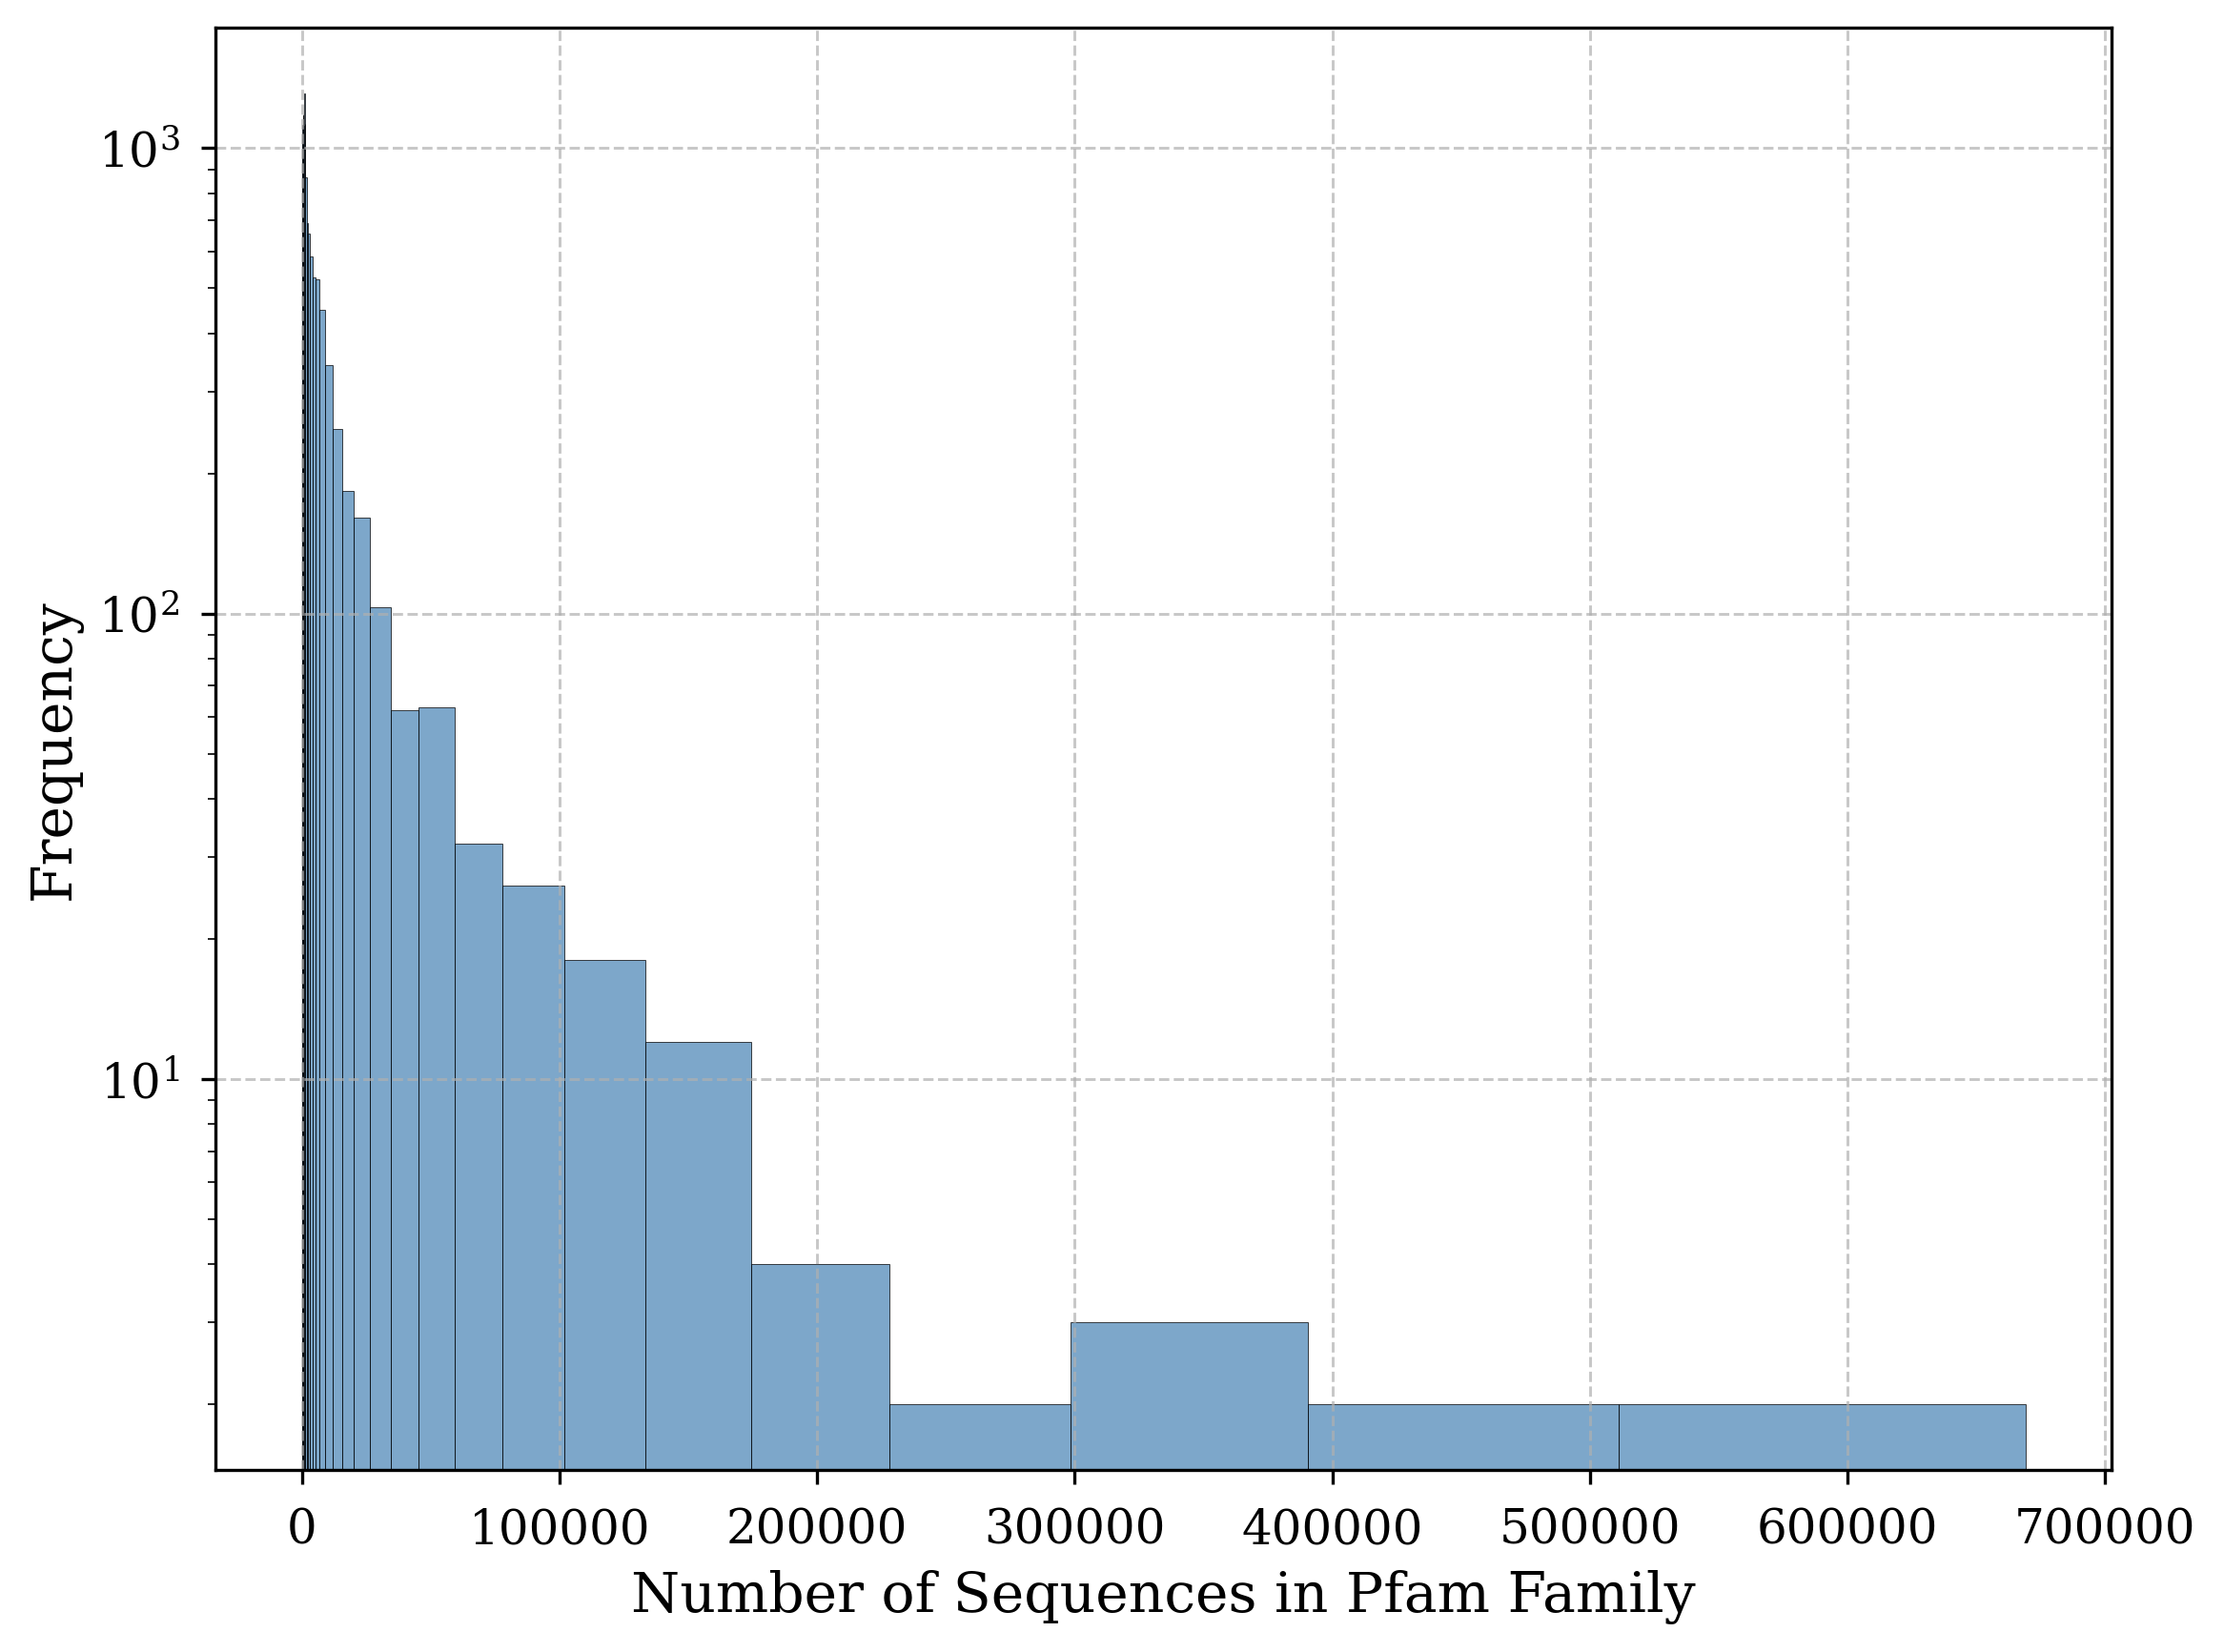

In [23]:
plot_histogram(sequences_per_family, xlabel="Number of Sequences in Pfam Family")

# Analyze the number of sequences belonging to a single family

In [55]:
# Compute the number of times a Uniprot ID occurs in the dataset (across all of the Pfams)
uniprot_counts = Counter(chain.from_iterable(families.values()))
all_counts = list(uniprot_counts.values())

In [56]:
# Print statistics
print(f"Total number of Uniprot IDs (across all families): {len(all_uniprot_ids)}")
print(f"Number of unique Uniprot IDs: {len(all_counts)}")

# Calculate the number of uniprot IDs occuring only in a single family
num_uids_in_single_family = sum(x == 1 for x in all_counts)
print(f"The number of uniprot IDs occuring only in a single family (unique IDs) {num_uids_in_single_family}")

Total number of Uniprot IDs (across all families): 56937050
Number of unique Uniprot IDs: 38979839
The number of uniprot IDs occuring only in a single family (unique IDs) 27875440


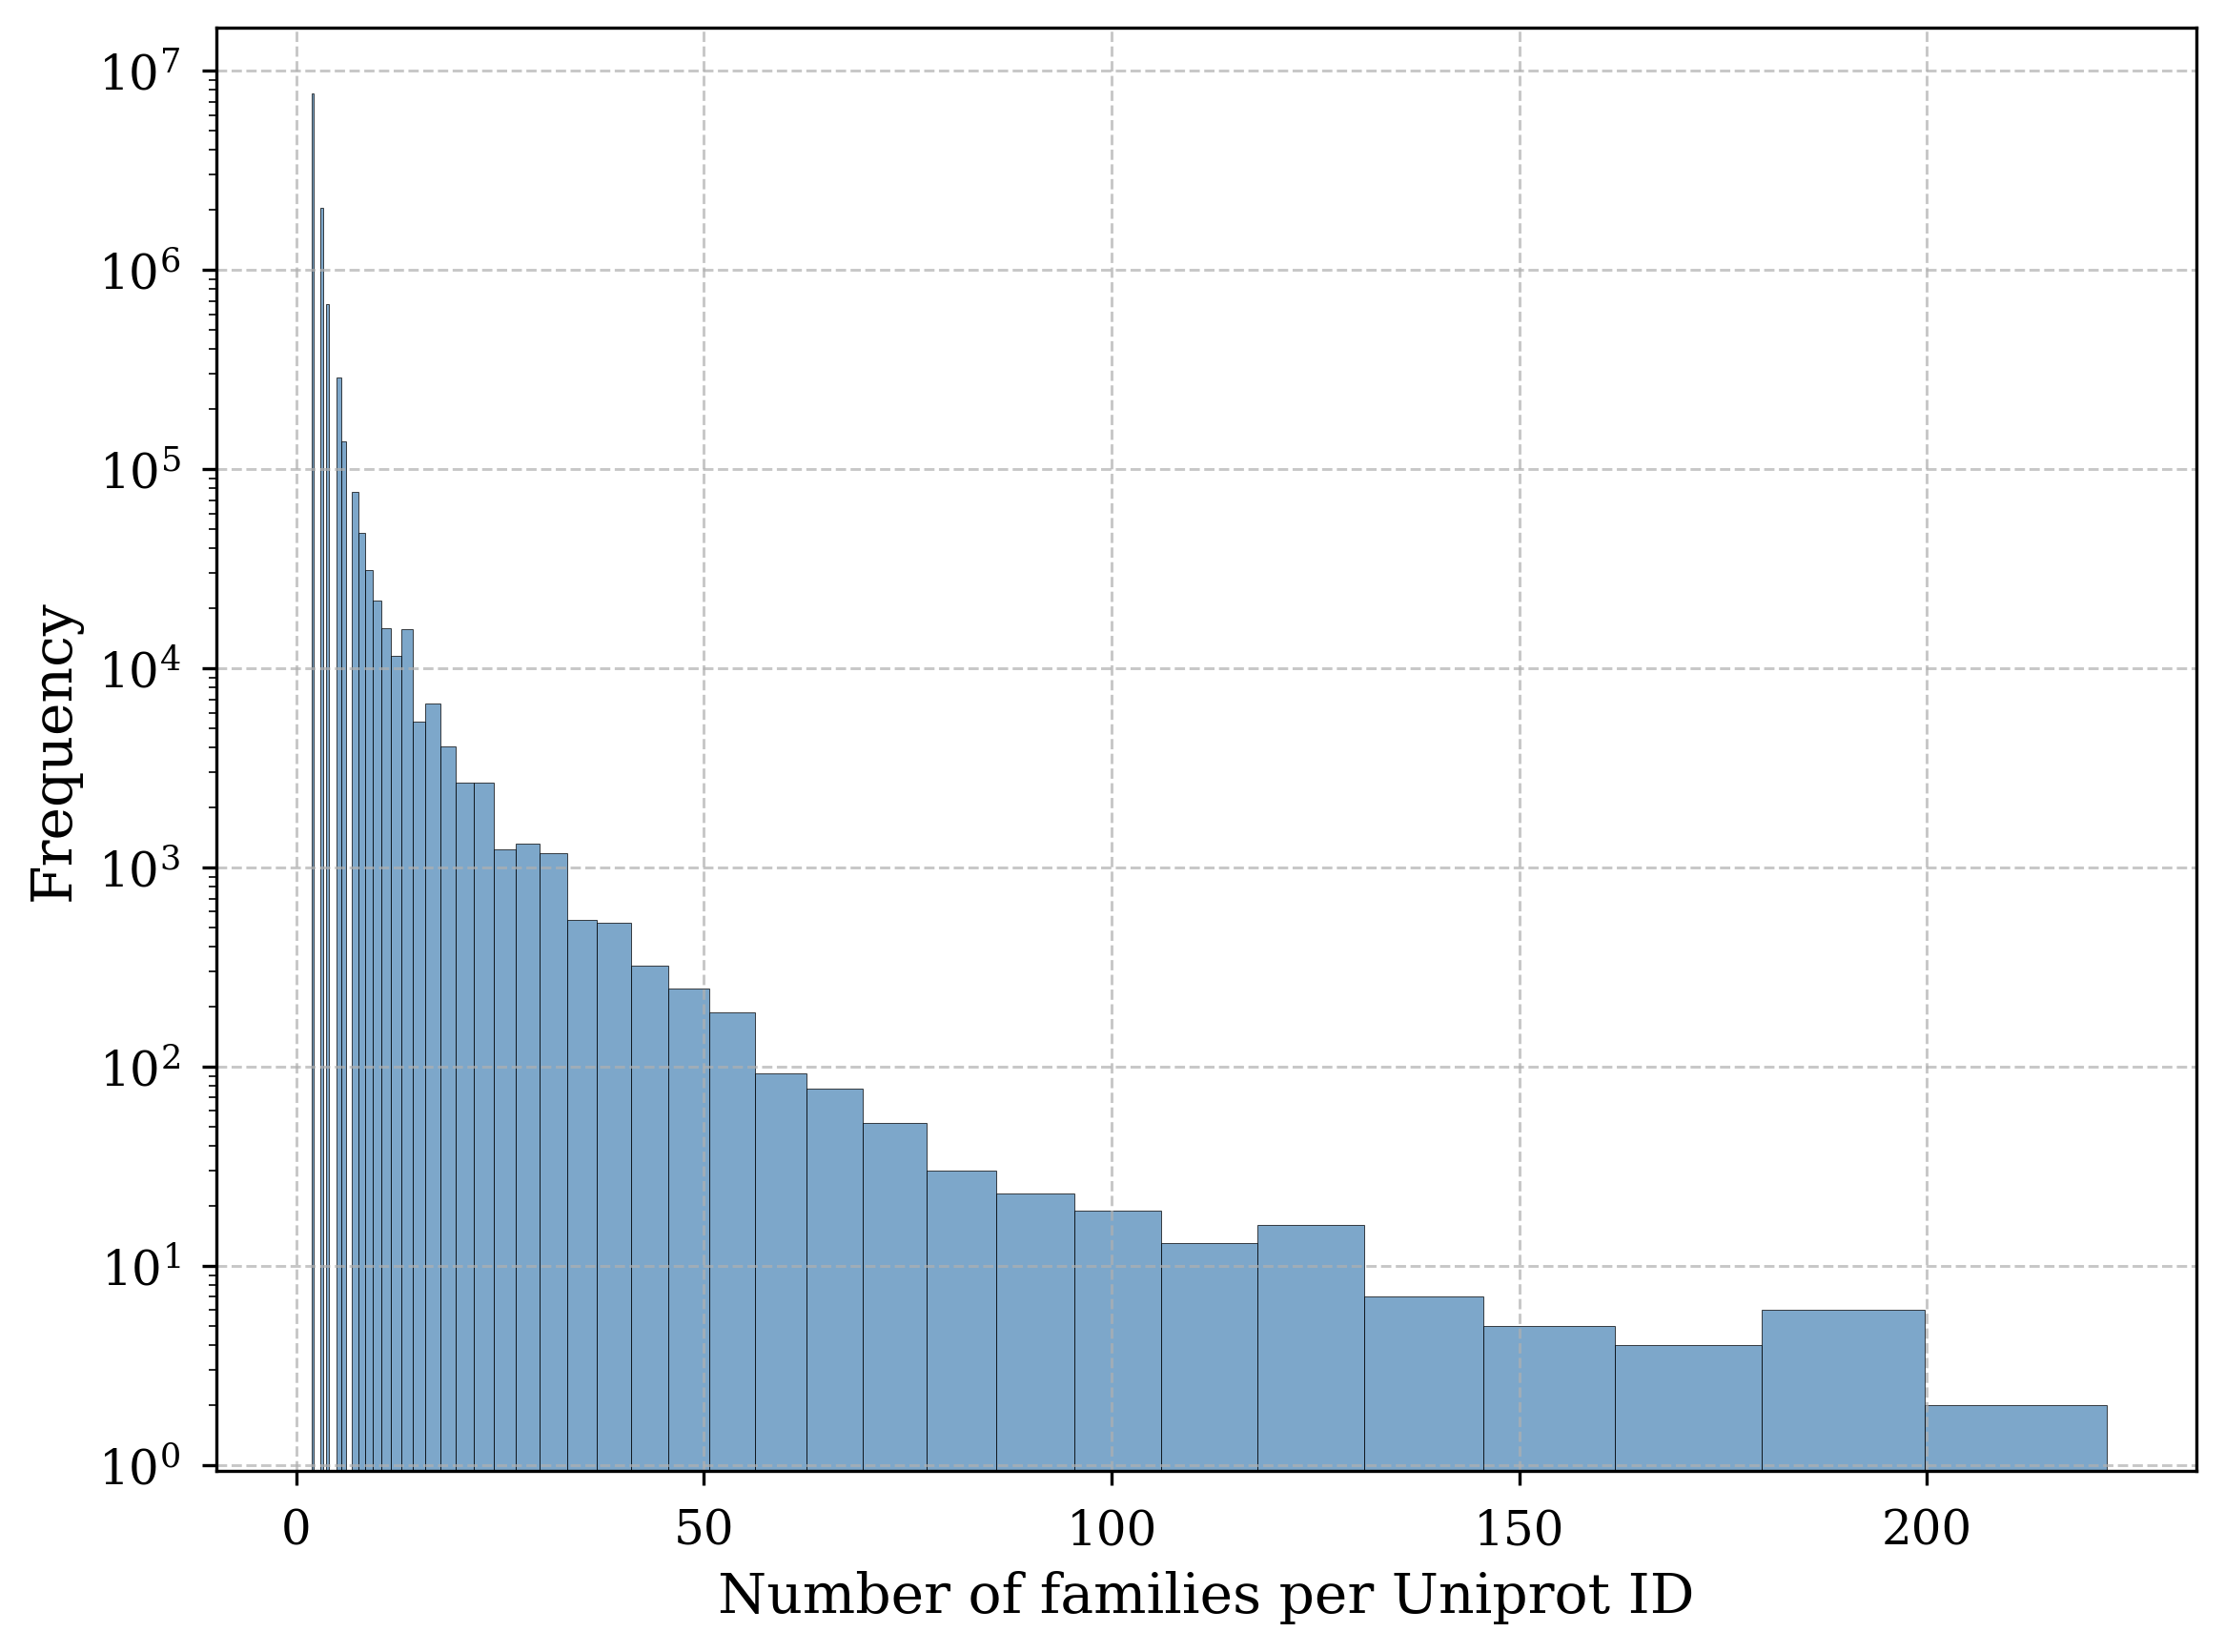

In [57]:
plot_histogram(all_counts, xlabel="Number of families per Uniprot ID")

In [65]:
families_uniq = {
    pfam_id: [x for x in uniprot_ids if uniprot_counts[x] == 1]
    for pfam_id, uniprot_ids in tqdm(families.items())
}

100%|██████████████████████████████████████████████████████████████████████| 21845/21845 [00:23<00:00, 919.99it/s]


In [66]:
uniprot_uniq_counts = Counter(chain.from_iterable(families_uniq.values()))
all_uniq_counts = list(uniprot_uniq_counts.values())
len(all_uniq_counts)

27875440

In [67]:
# Precompute uniprot_ids with count == 1
unique_uniprot_ids = {x for x, count in uniprot_counts.items() if count == 1}

In [68]:
len(unique_uniprot_ids)

27875440

In [69]:
# Use set lookup for faster filtering
families_uniq = {
    pfam_id: [x for x in uniprot_ids if x in unique_uniprot_ids]
    for pfam_id, uniprot_ids in tqdm(families.items())
}

100%|██████████████████████████████████████████████████████████████████████| 21845/21845 [00:23<00:00, 939.36it/s]


In [71]:
uniprot_uniq_counts = Counter(chain.from_iterable(families_uniq.values()))
all_uniq_counts = list(uniprot_uniq_counts.values())
len(all_uniq_counts)

27875440

# Plot the length distirbution of Pfam20

In [11]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')

In [4]:
families = dataset.load_families()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json
Number of families before length filtering: 21845
Number of families after length filtering: 19106
Randomly selecting 20 domains from each family to balance the dataset using random seed: 42
Saving Pfam20 families metadata to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/families.json


In [5]:
sequences_per_family = [len(value) for key, value in families.items()]
all(x == 20 for x in sequences_per_family)

False

In [7]:
sum(x for x in sequences_per_family)

381300

**Note:** The Pfam20 dataset has 19,106 * 20 = 382,120 sequences

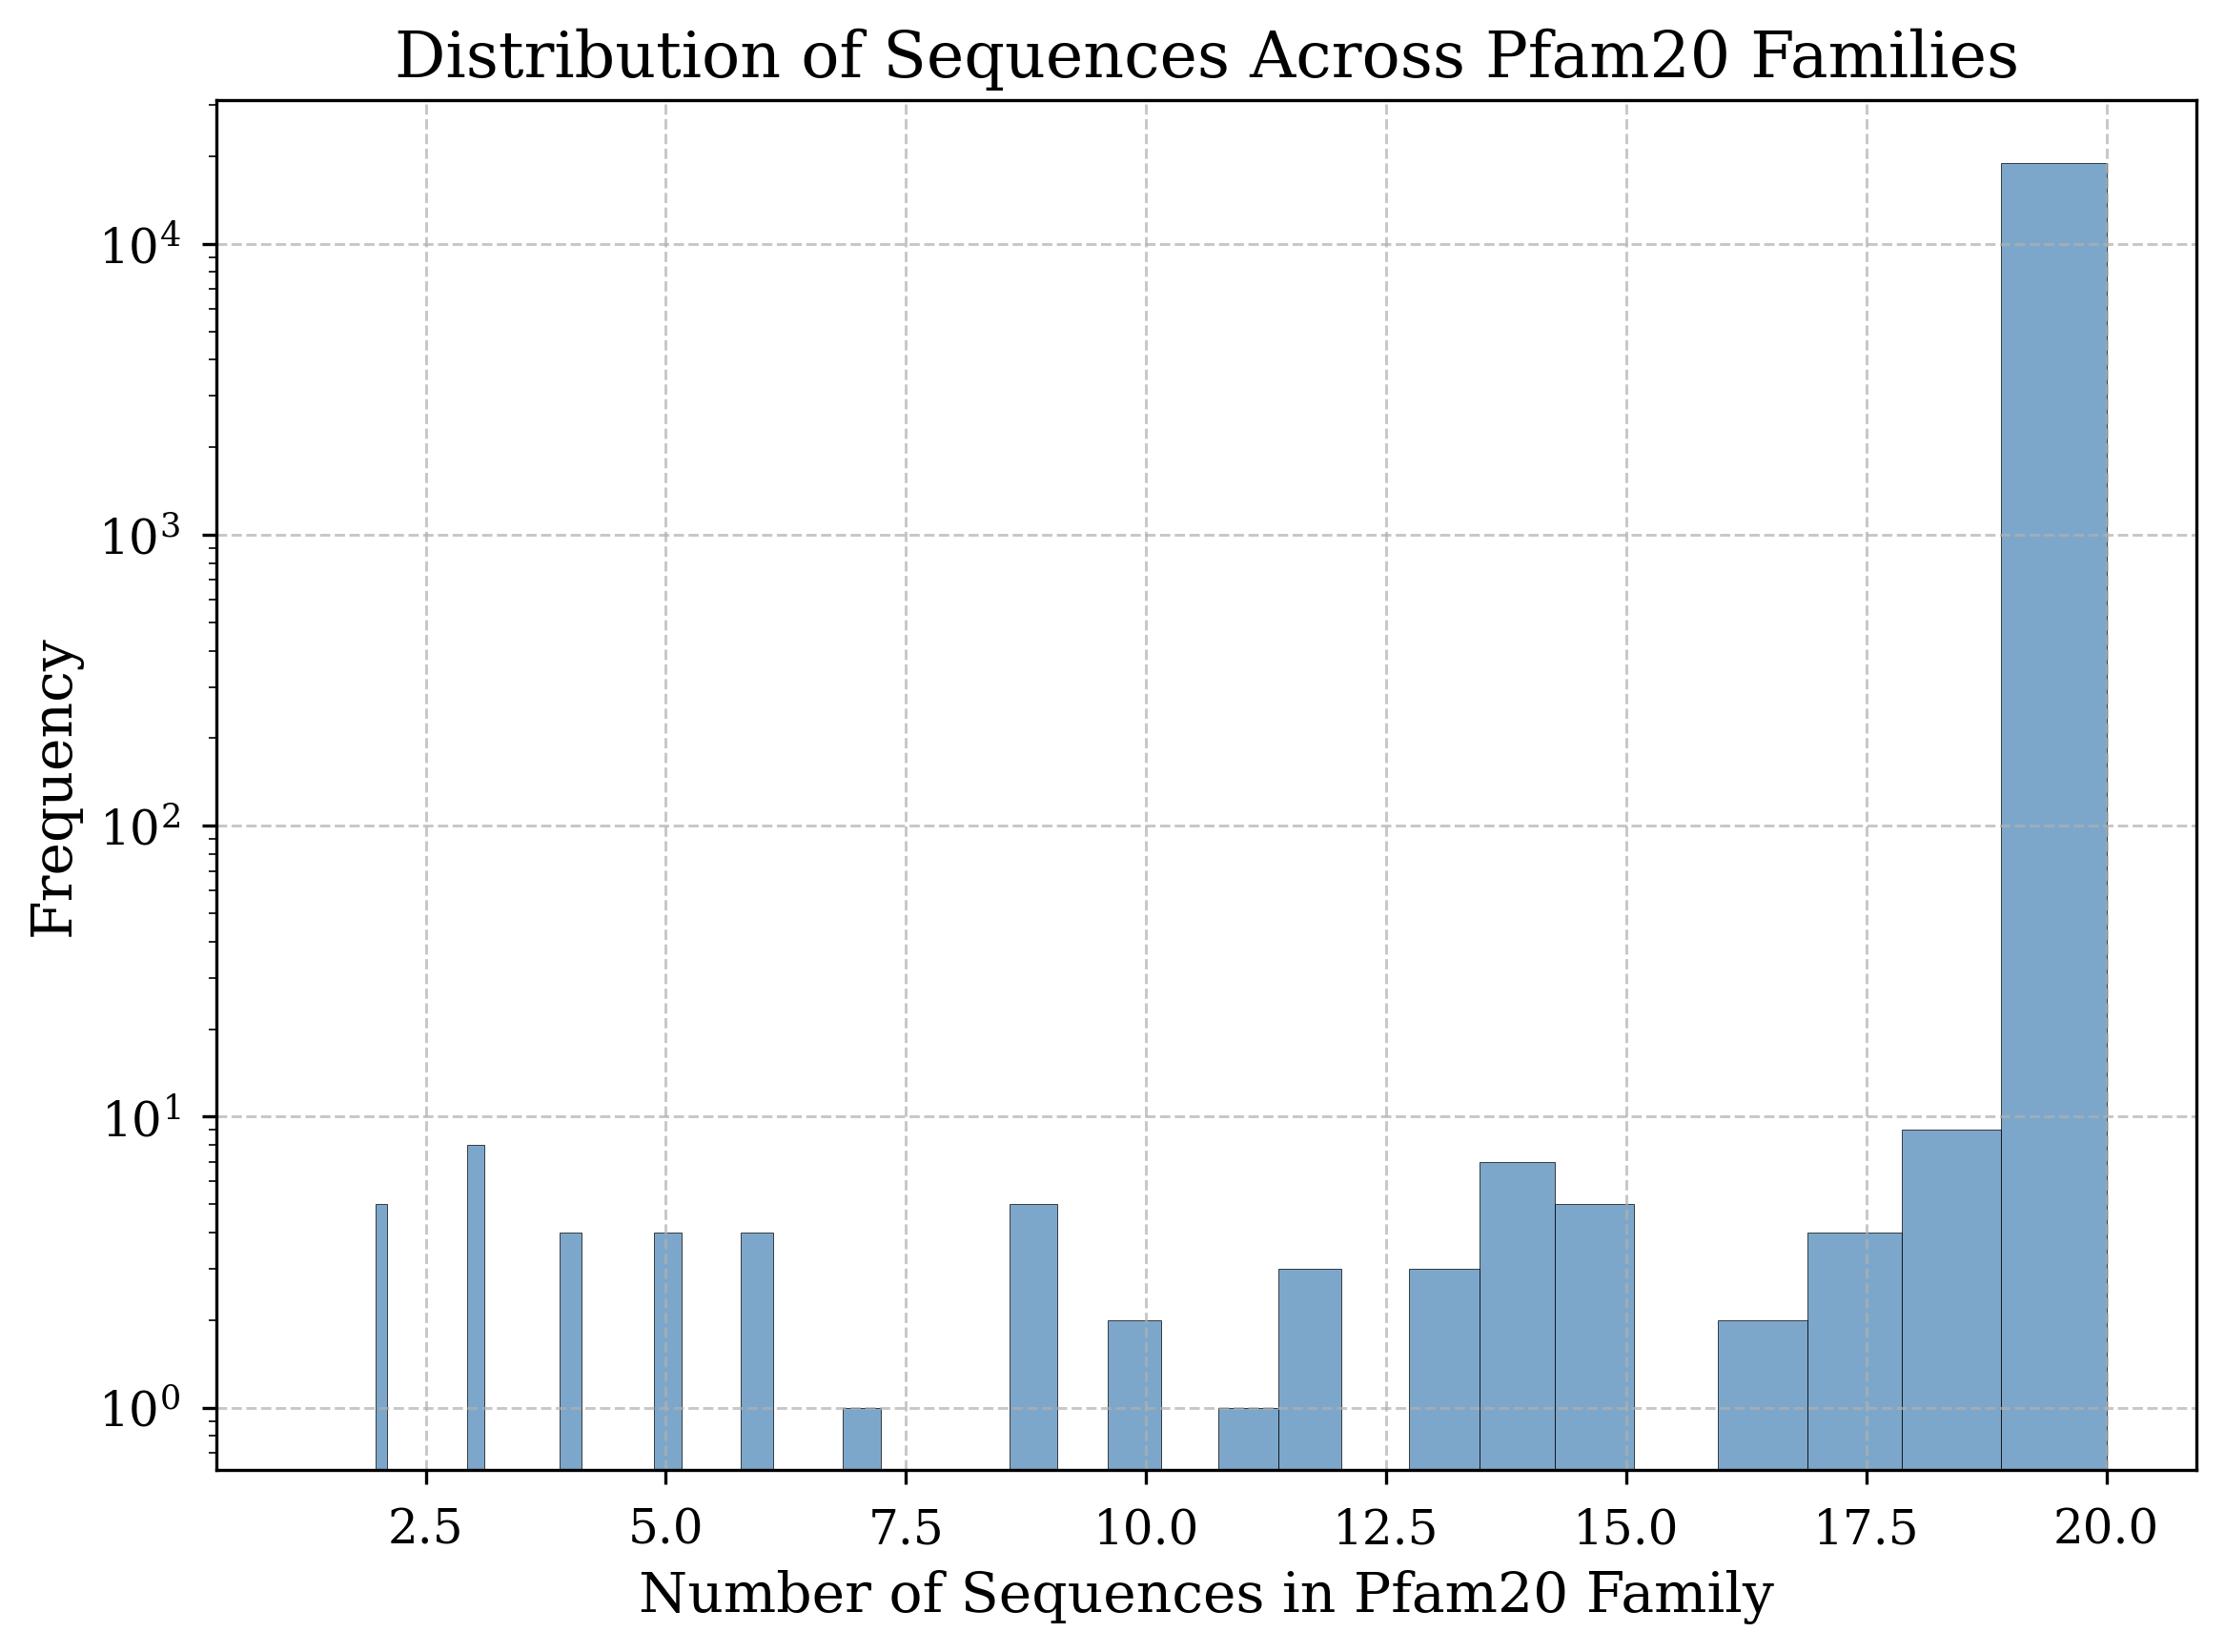

In [6]:
plot_histogram(sequences_per_family, xlabel="Number of Sequences in Pfam20 Family")

In [20]:
# Example of how a family looks:
for key, value in families.items():
    print(f"Pfam: {key}")
    print(f"Sequences Uniprot IDs: {value}")
    break

Pfam: PF10417.14
Sequences Uniprot IDs: ['A0A151I178.1', 'A0A4R5MMC7.1', 'A4YGX9.1', 'A0A8S3WLJ1.1', 'A0A1D2N006.1', 'A0A8J7J063.1', 'A0A8K0JUP7.1', 'A0A183MLJ7.1', 'A0A0K2SR66.1', 'A0A194SAZ8.1', 'A0A3M6Z511.1', 'A0A1I4U9Q4.1', 'S3XI78.1', 'H1XUL3.1', 'A0A0A1TGV0.1', 'J3MNE5.1', 'A0A8J3CSD1.1', 'A0A178MLE3.1', 'A0A8T3CJ61.1', 'A0A2K1PXW6.1']


In [21]:
uniprot_ids = {x for y in families.values() for x in y}

In [22]:
len(uniprot_ids)

377392

In [12]:
families = dataset.load_families()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json
Number of families before length filtering: 21845
Number of families after length filtering: 19106
Randomly selecting 20 domains from each family to balance the dataset using random seed: 42
Saving Pfam20 families metadata to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/families.json


In [13]:
sequences_per_family = [len(value) for key, value in families.items()]
all(x == 20 for x in sequences_per_family)

False

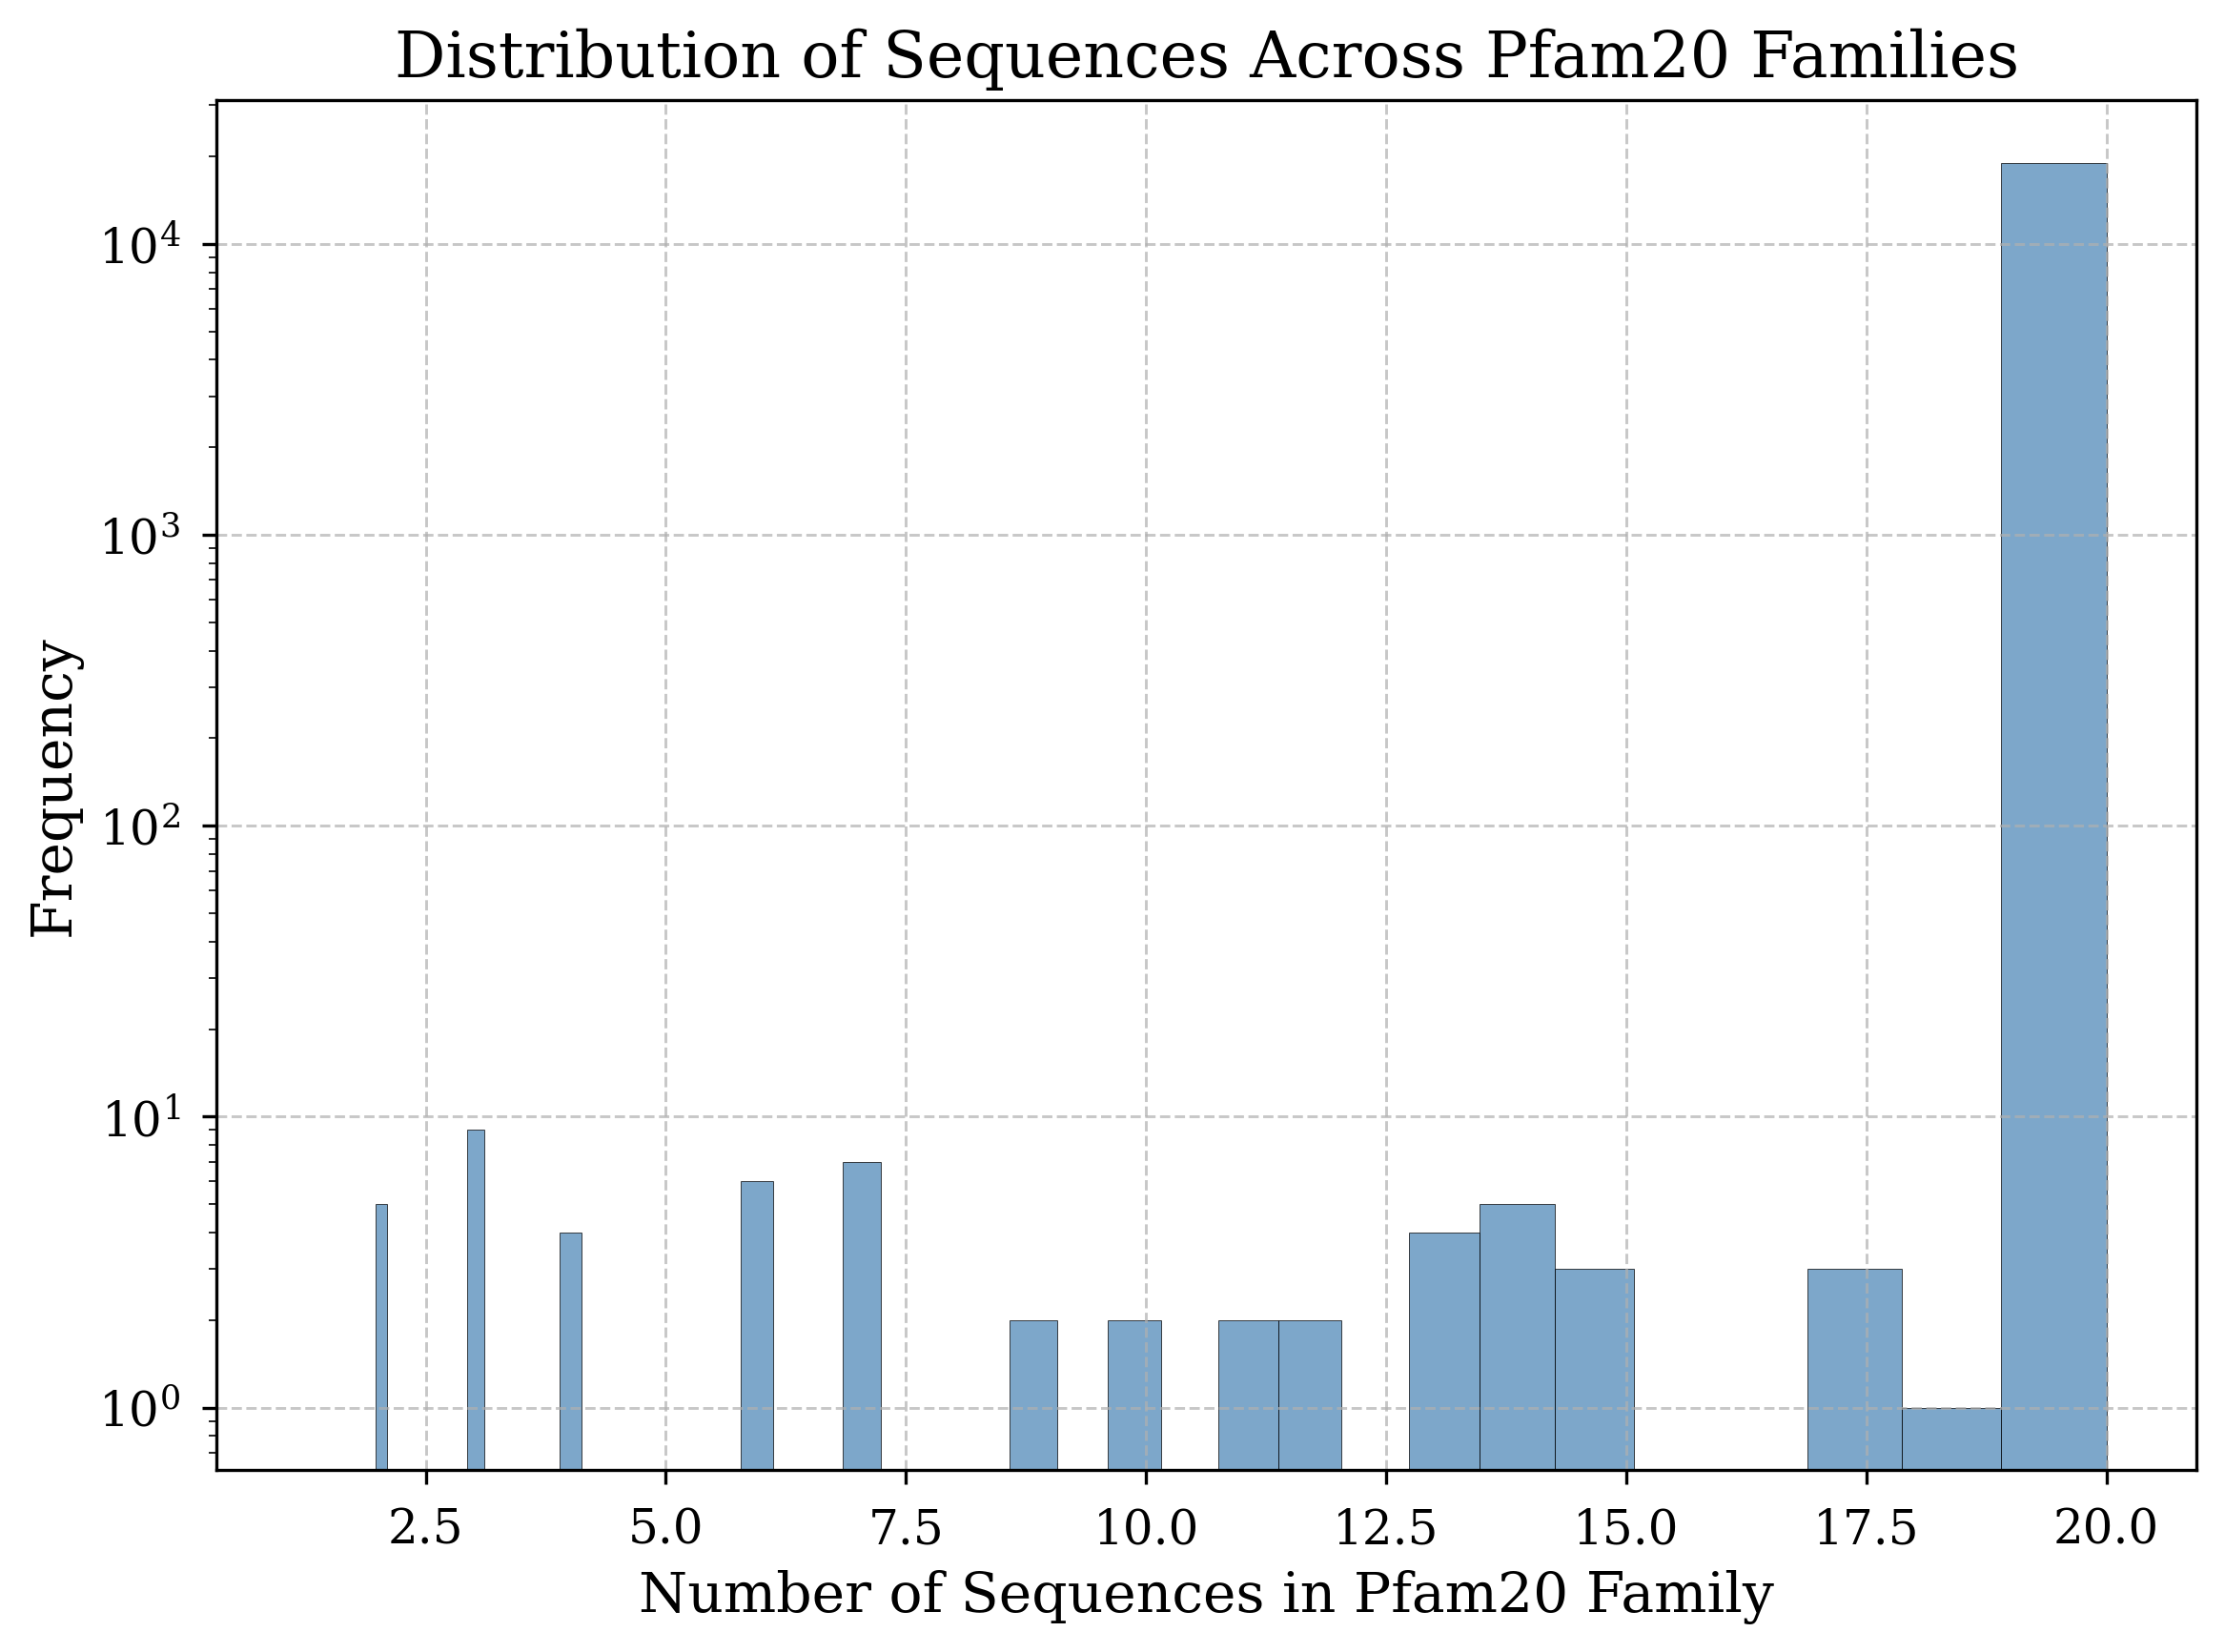

In [14]:
plot_length_histogram(sequences_per_family, "Pfam20")

In [15]:
sum(x for x in sequences_per_family)

381418

In [21]:
# Check the number of families with less than 20 sequences
from collections import Counter
count = Counter(sequences_per_family)
dict(sorted(count.items(), key=lambda x: x[0]))

{1: 3,
 2: 5,
 3: 9,
 4: 4,
 6: 6,
 7: 7,
 9: 2,
 10: 2,
 11: 2,
 12: 2,
 13: 4,
 14: 5,
 15: 3,
 17: 3,
 18: 1,
 19: 3,
 20: 19045}

In [22]:
sum(v for k, v in count.items() if k < 20)

61

61 pfams have less than 20 representatives in the benchmark

In [6]:
rm -r /homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42

In [7]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')

In [8]:
families = dataset.load_families()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing families with less than 20 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 17904
Randomly selecting 20 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27851528
	Num. Uniprot IDs after filtering: 358080
Saving Pfam20 families metadata to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/families.json


In [9]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy')

In [10]:
families = dataset.load_families()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   115  100   115    0     0     53      0  0:00:02  0:00:02 --:--:--    53
/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/Pfam.version.gz:	 24.3% -- replaced with /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/Pfam.version
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

Downloaded and unzipped: /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/Pfam.version


100 5325M  100 5325M    0     0   144M      0  0:00:36  0:00:36 --:--:--  151M
/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/Pfam-A.fasta.gz:	 54.5% -- replaced with /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/Pfam-A.fasta
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

Downloaded and unzipped: /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/Pfam-A.fasta


100 20.3G  100 20.3G    0     0   151M      0  0:02:17  0:02:17 --:--:--  152M
/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfamseq.gz:	 46.0% -- replaced with /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfamseq


Downloaded and unzipped: /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfamseq


Parsing Pfam families: 100%|█████████████████████████████████████| 56937050/56937050 [00:40<00:00, 1423040.25it/s]


Saving Pfam families metadata to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing families with less than 20 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 17904
Randomly selecting 20 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27851528
	Num. Uniprot IDs after filtering: 358080
Saving Pfam20 families metadata to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfam20_seed-42/families.json


In [19]:
len(families)

17904

# Analyze the number of families and number of sequences as a function of the subset_size threshold

In [25]:
data_dir = Path('/nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy')

# Collect the number of families and sequences at each subset_size value
subset_sizes = []
num_families = []
num_sequences = []

# Try every subset from 5 to 100, incrementing by 5 (i.e.: 5, 10, ... 95, 100)
for subset_size in tqdm(range(5, 101, 5), desc='Subset sizes'):
    print(f'Building families for subset size {subset_size}')
    
    # Create the dataset using the given subset
    dataset = PfamSubsetDataset(data_dir=data_dir, subset_size=subset_size)
    
    # Create the families subset
    families = dataset.load_families()

    # Compute the number of sequences (i.e., Uniprot IDs) across the families
    num_uniprot_ids = sum(len(v) for v in families.values())

    # Collect outputs
    subset_sizes.append(subset_size)
    num_families.append(len(families))
    num_sequences.append(num_uniprot_ids)

Subset sizes:   0%|                                                                        | 0/20 [00:00<?, ?it/s]

Building families for subset size 5
Loading Pfam families metadata from /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing families with less than 5 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 19792
Randomly selecting 5 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27872294
	Num. Uniprot IDs after filtering: 98960
Saving Pfam5 families metadata to /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfam5_seed-42/families.json


Subset sizes:   5%|███▏                                                            | 1/20 [01:06<20:58, 66.22s/it]

Building families for subset size 10
Loading Pfam families metadata from /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing families with less than 10 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 18971
Randomly selecting 10 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27866755


Subset sizes:  10%|██████▍                                                         | 2/20 [02:16<20:34, 68.61s/it]

...

Subset sizes:  90%|████████████████████████████████████████████████████████▋      | 18/20 [21:33<02:25, 72.73s/it]

Building families for subset size 95
Loading Pfam families metadata from /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing families with less than 95 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 14097
Randomly selecting 95 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27657968
	Num. Uniprot IDs after filtering: 1339215
Saving Pfam95 families metadata to /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfam95_seed-42/families.json


Subset sizes:  95%|███████████████████████████████████████████████████████████▊   | 19/20 [22:53<01:14, 74.88s/it]

Building families for subset size 100
Loading Pfam families metadata from /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing families with less than 100 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 13930
Randomly selecting 100 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27641748
	Num. Uniprot IDs after filtering: 1393000
Saving Pfam100 families metadata to /nfs/lambda_stor_01/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam-copy/pfam100_seed-42/families.json


Subset sizes: 100%|███████████████████████████████████████████████████████████████| 20/20 [24:09<00:00, 72.48s/it]


In [30]:
# Collect outputs
data = {
    "subset_sizes": subset_sizes,
    "num_families": num_families,
    "num_sequences": num_sequences,
}

# Save to JSON file
with open(data_dir / "pfam_subset_stats.json", "w") as f:
    json.dump(data, f, indent=4)

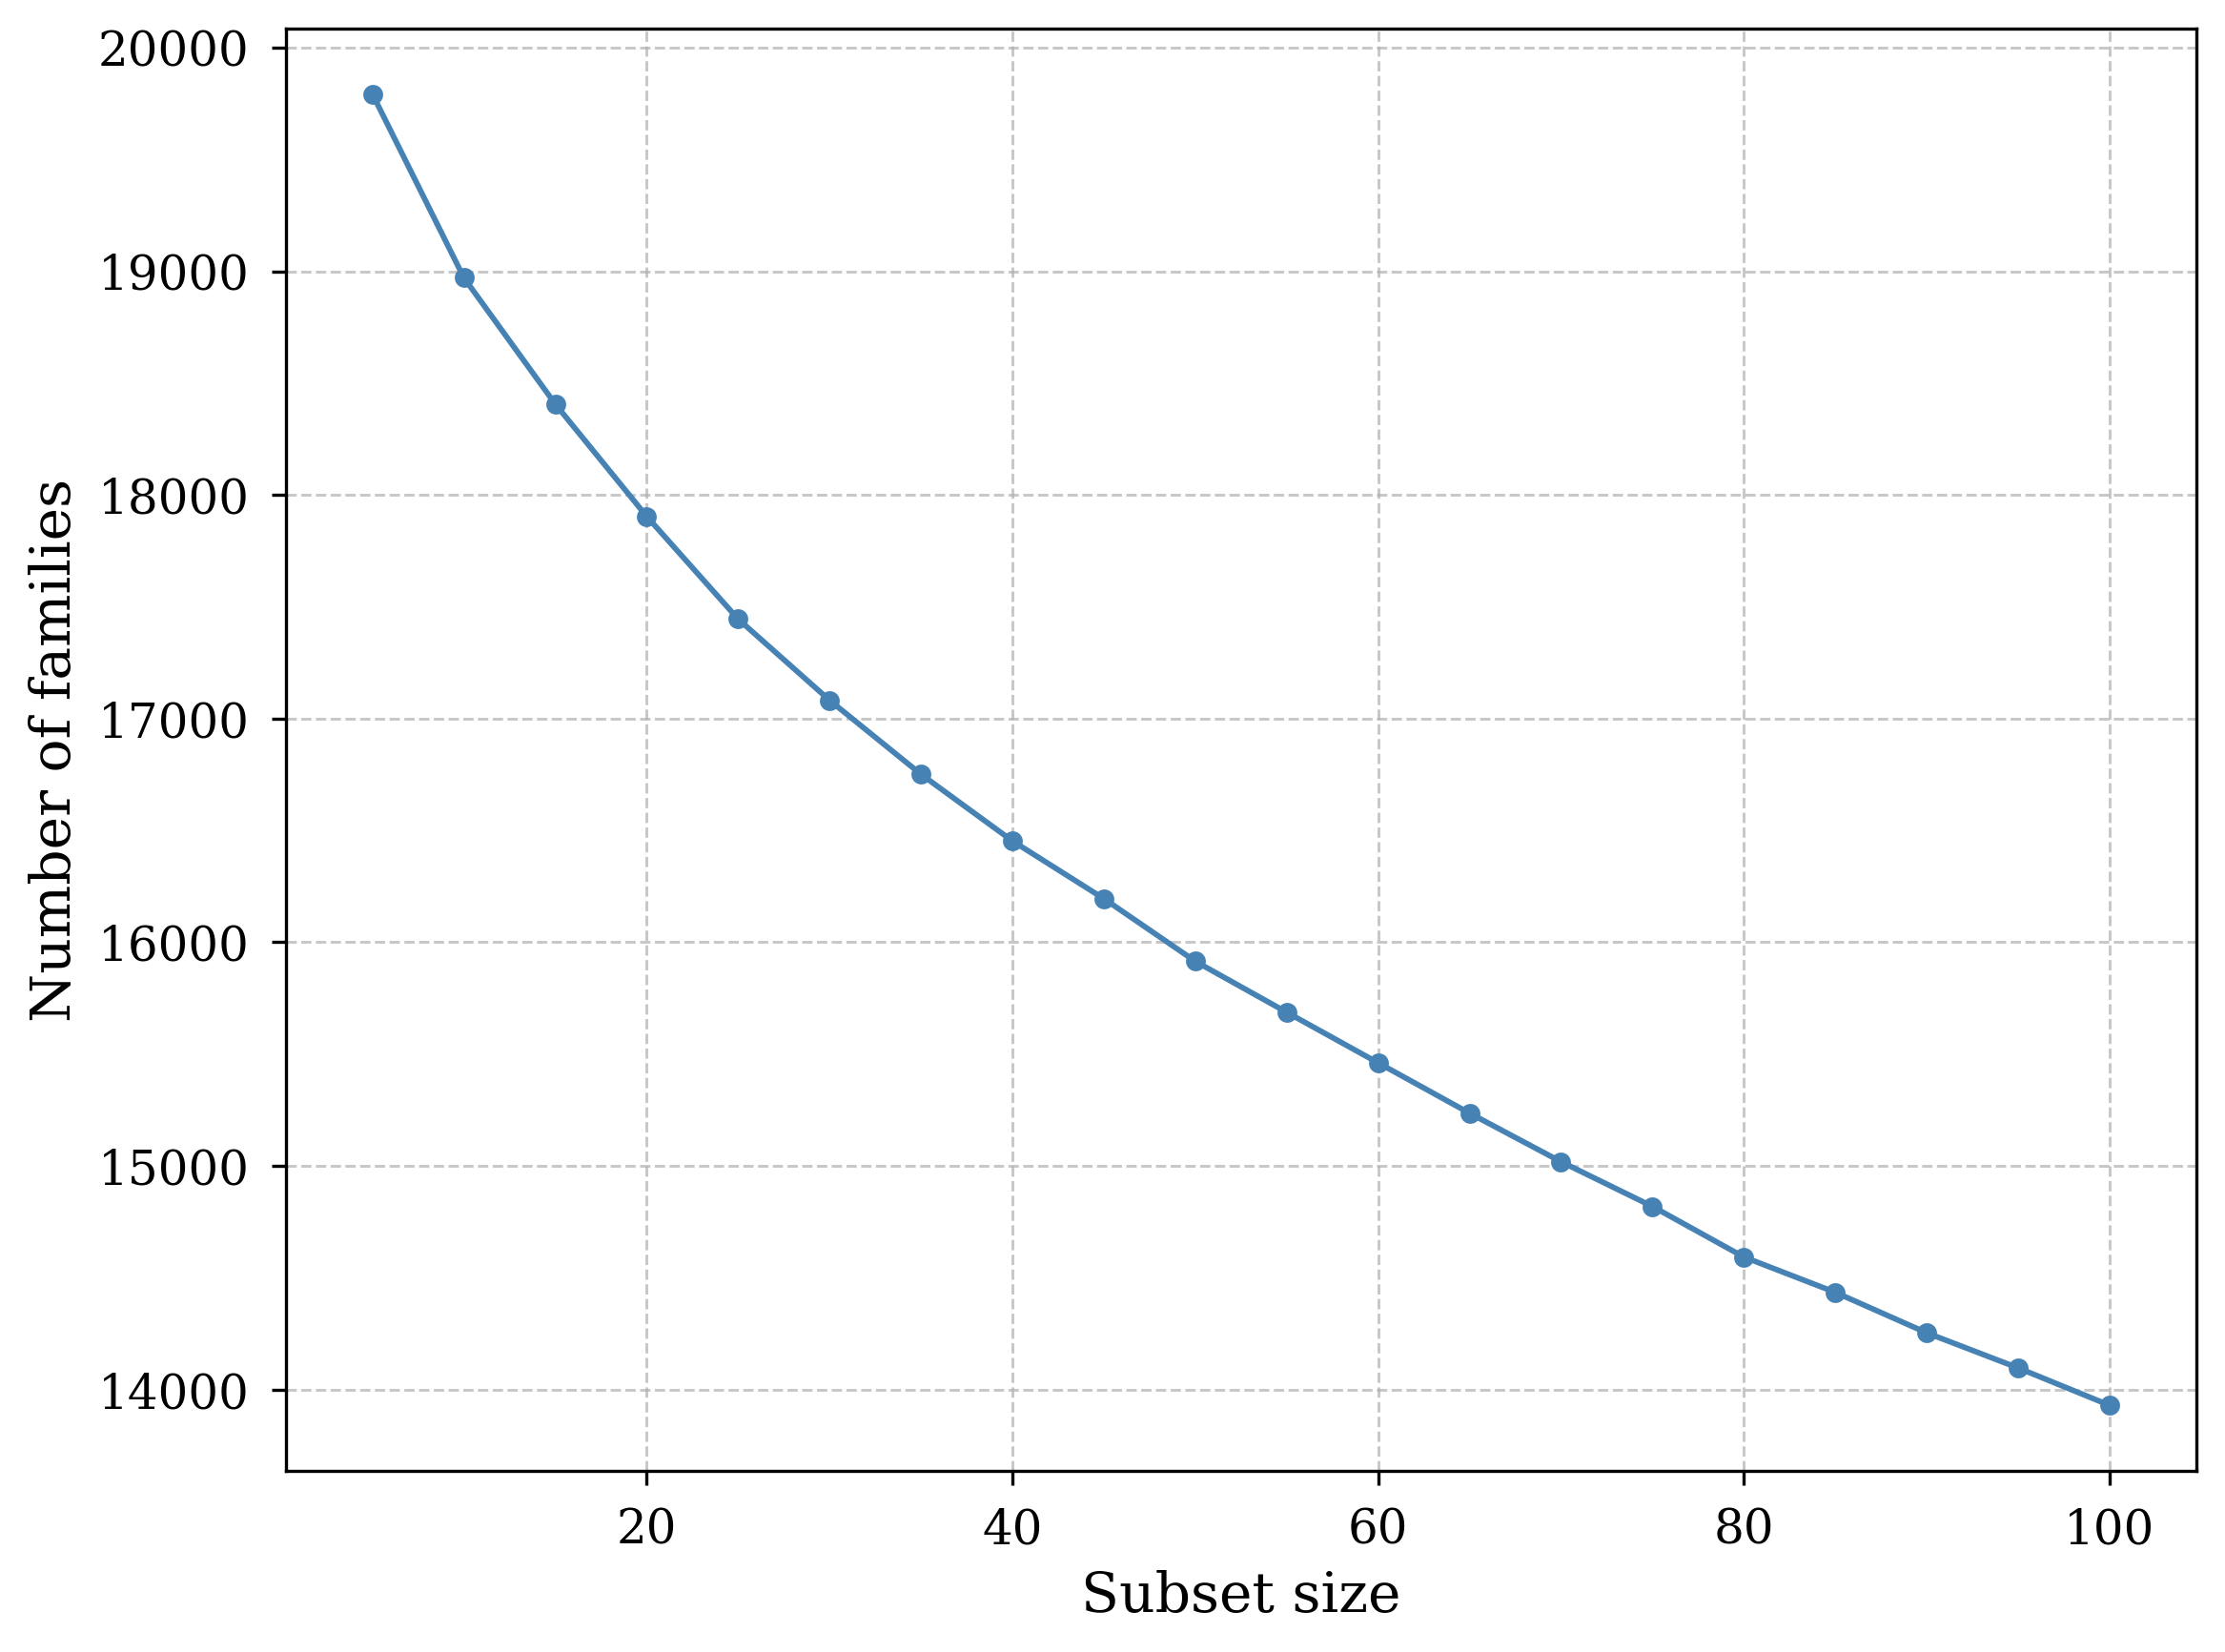

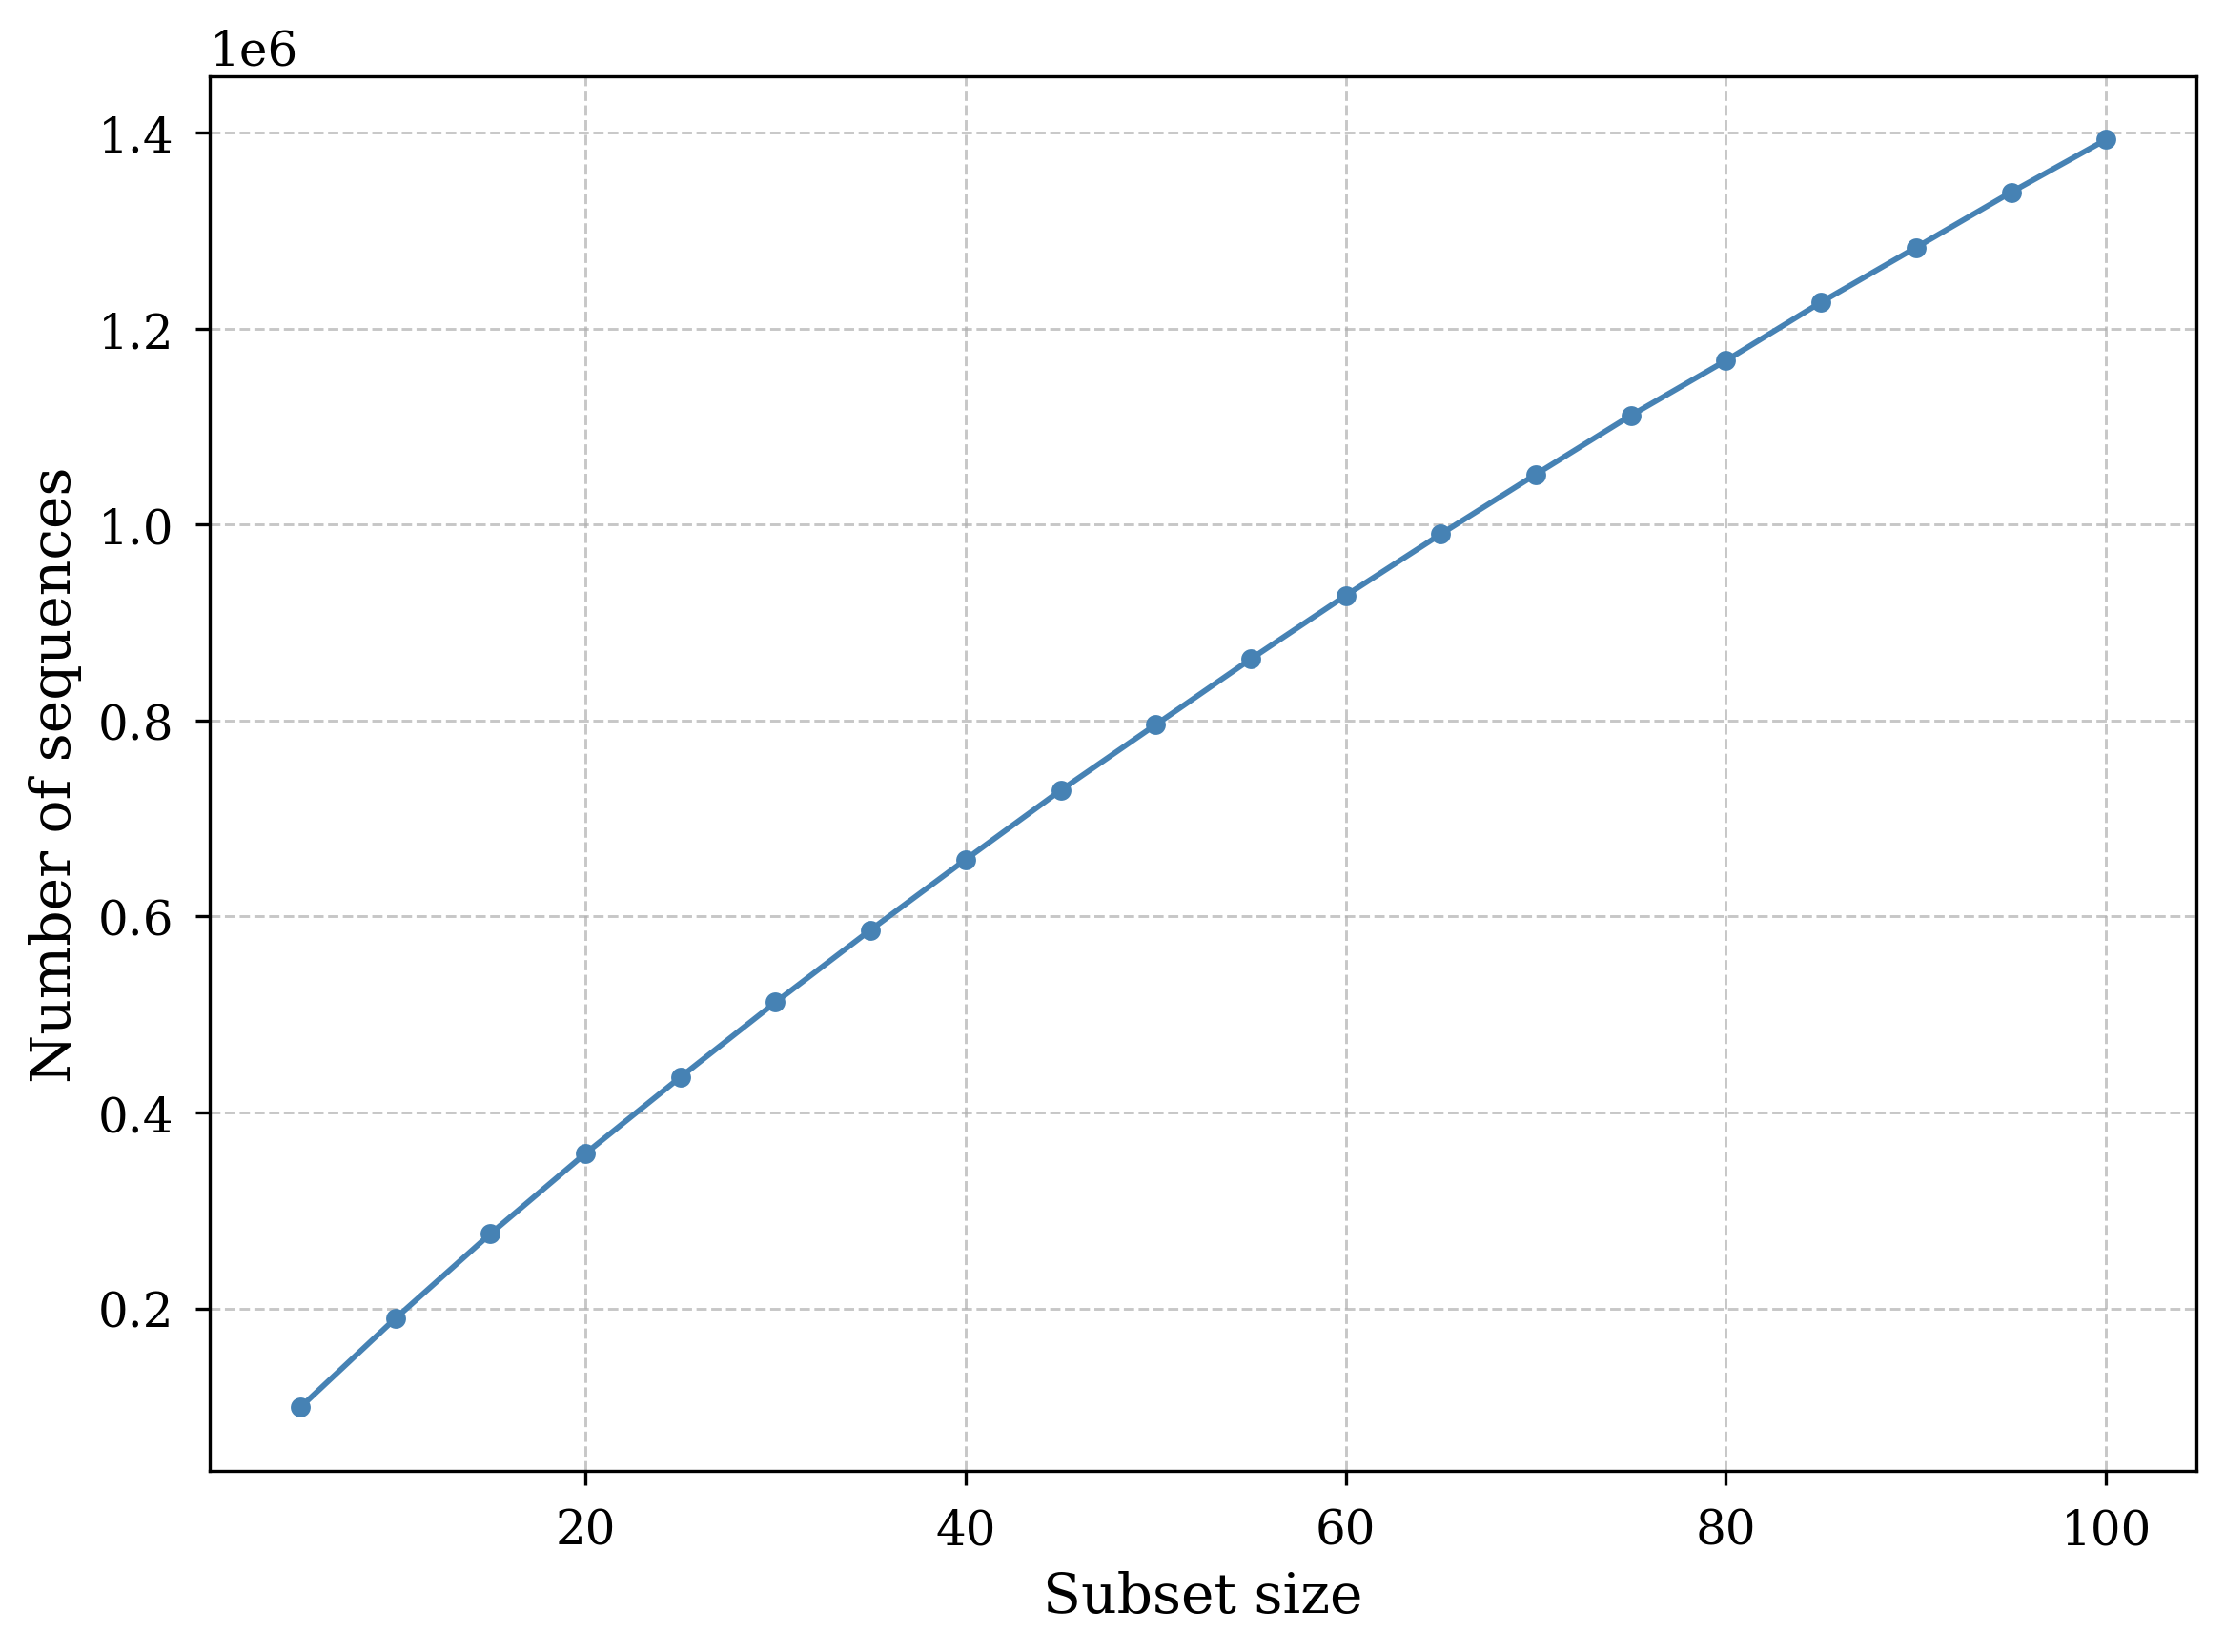

In [44]:
# Load from JSON file
with open(data_dir / "pfam_subset_stats.json", "r") as f:
    data = json.load(f)

# Populate variables
subset_sizes = data["subset_sizes"]
num_families = data["num_families"]
num_sequences = data["num_sequences"]

# Plot the data
plot_line_chart(x=subset_sizes, y=num_families, xlabel='Subset size', ylabel='Number of families')
plot_line_chart(x=subset_sizes, y=num_sequences, xlabel='Subset size', ylabel='Number of sequences')

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull
from matplotlib.lines import Line2D

def plot_pareto_front(
    subset_sizes: list[int],
    num_families: list[int],
    num_sequences: list[int],
    xlabel: str = "Number of Families",
    ylabel: str = "Number of Sequences",
    title: str = "Pareto Front for Optimal Subset Size",
    save_path: str | None = None,
) -> None:
    """
    Plot a Pareto front for the trade-off between num_families and num_sequences.

    Parameters
    ----------
    subset_sizes : list[int]
        List of subset size values.
    num_families : list[int]
        Number of families corresponding to each subset size.
    num_sequences : list[int]
        Number of sequences corresponding to each subset size.
    xlabel : str, optional
        Label for the x-axis, by default "Number of Families".
    ylabel : str, optional
        Label for the y-axis, by default "Number of Sequences".
    title : str, optional
        Title of the plot, by default "Pareto Front for Optimal Subset Size".
    save_path : str | None, optional
        If provided, saves the figure to the given path, by default None.

    Returns
    -------
    None
    """
    # Convert inputs to NumPy arrays
    families = np.array(num_families)
    sequences = np.array(num_sequences)
    sizes = np.array(subset_sizes)

    # Set up high-quality publication settings
    plt.style.use("seaborn-v0_8-paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 300,
    })

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter plot for all data points
    ax.scatter(families, sequences, color="steelblue", alpha=0.7, label="Subset Sizes")

    # Compute Pareto front using Convex Hull
    points = np.column_stack((families, sequences))
    hull = ConvexHull(points)

    # Extract Pareto front points
    pareto_indices = hull.vertices
    pareto_points = points[pareto_indices]
    pareto_points = pareto_points[np.argsort(pareto_points[:, 0])]  # Sort for smooth line

    # Plot the Pareto front as a dashed line
    ax.plot(pareto_points[:, 0], pareto_points[:, 1], color="crimson", linestyle="--", linewidth=2, label="Pareto Front")

    # Identify and annotate the optimal points (Pareto-efficient points)
    optimal_points = set(map(tuple, pareto_points))
    for x, y, size in zip(families, sequences, sizes):
        if (x, y) in optimal_points:
            ax.scatter(x, y, color="red", s=80, edgecolors="black", zorder=3)  # Highlight optima
            ax.text(x, y, f"{size}", fontsize=10, ha="right", va="bottom", color="black", fontweight="bold")

    # Customize the plot
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

    # Custom legend
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="Subset Sizes"),
        Line2D([0], [0], color="crimson", linestyle="--", linewidth=2, label="Pareto Front"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markeredgecolor="black", markersize=8, label="Pareto-optimal Points"),
    ]
    ax.legend(handles=legend_elements, loc="best")

    # Optimize layout
    plt.tight_layout()

    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # Show the plot
    plt.show()


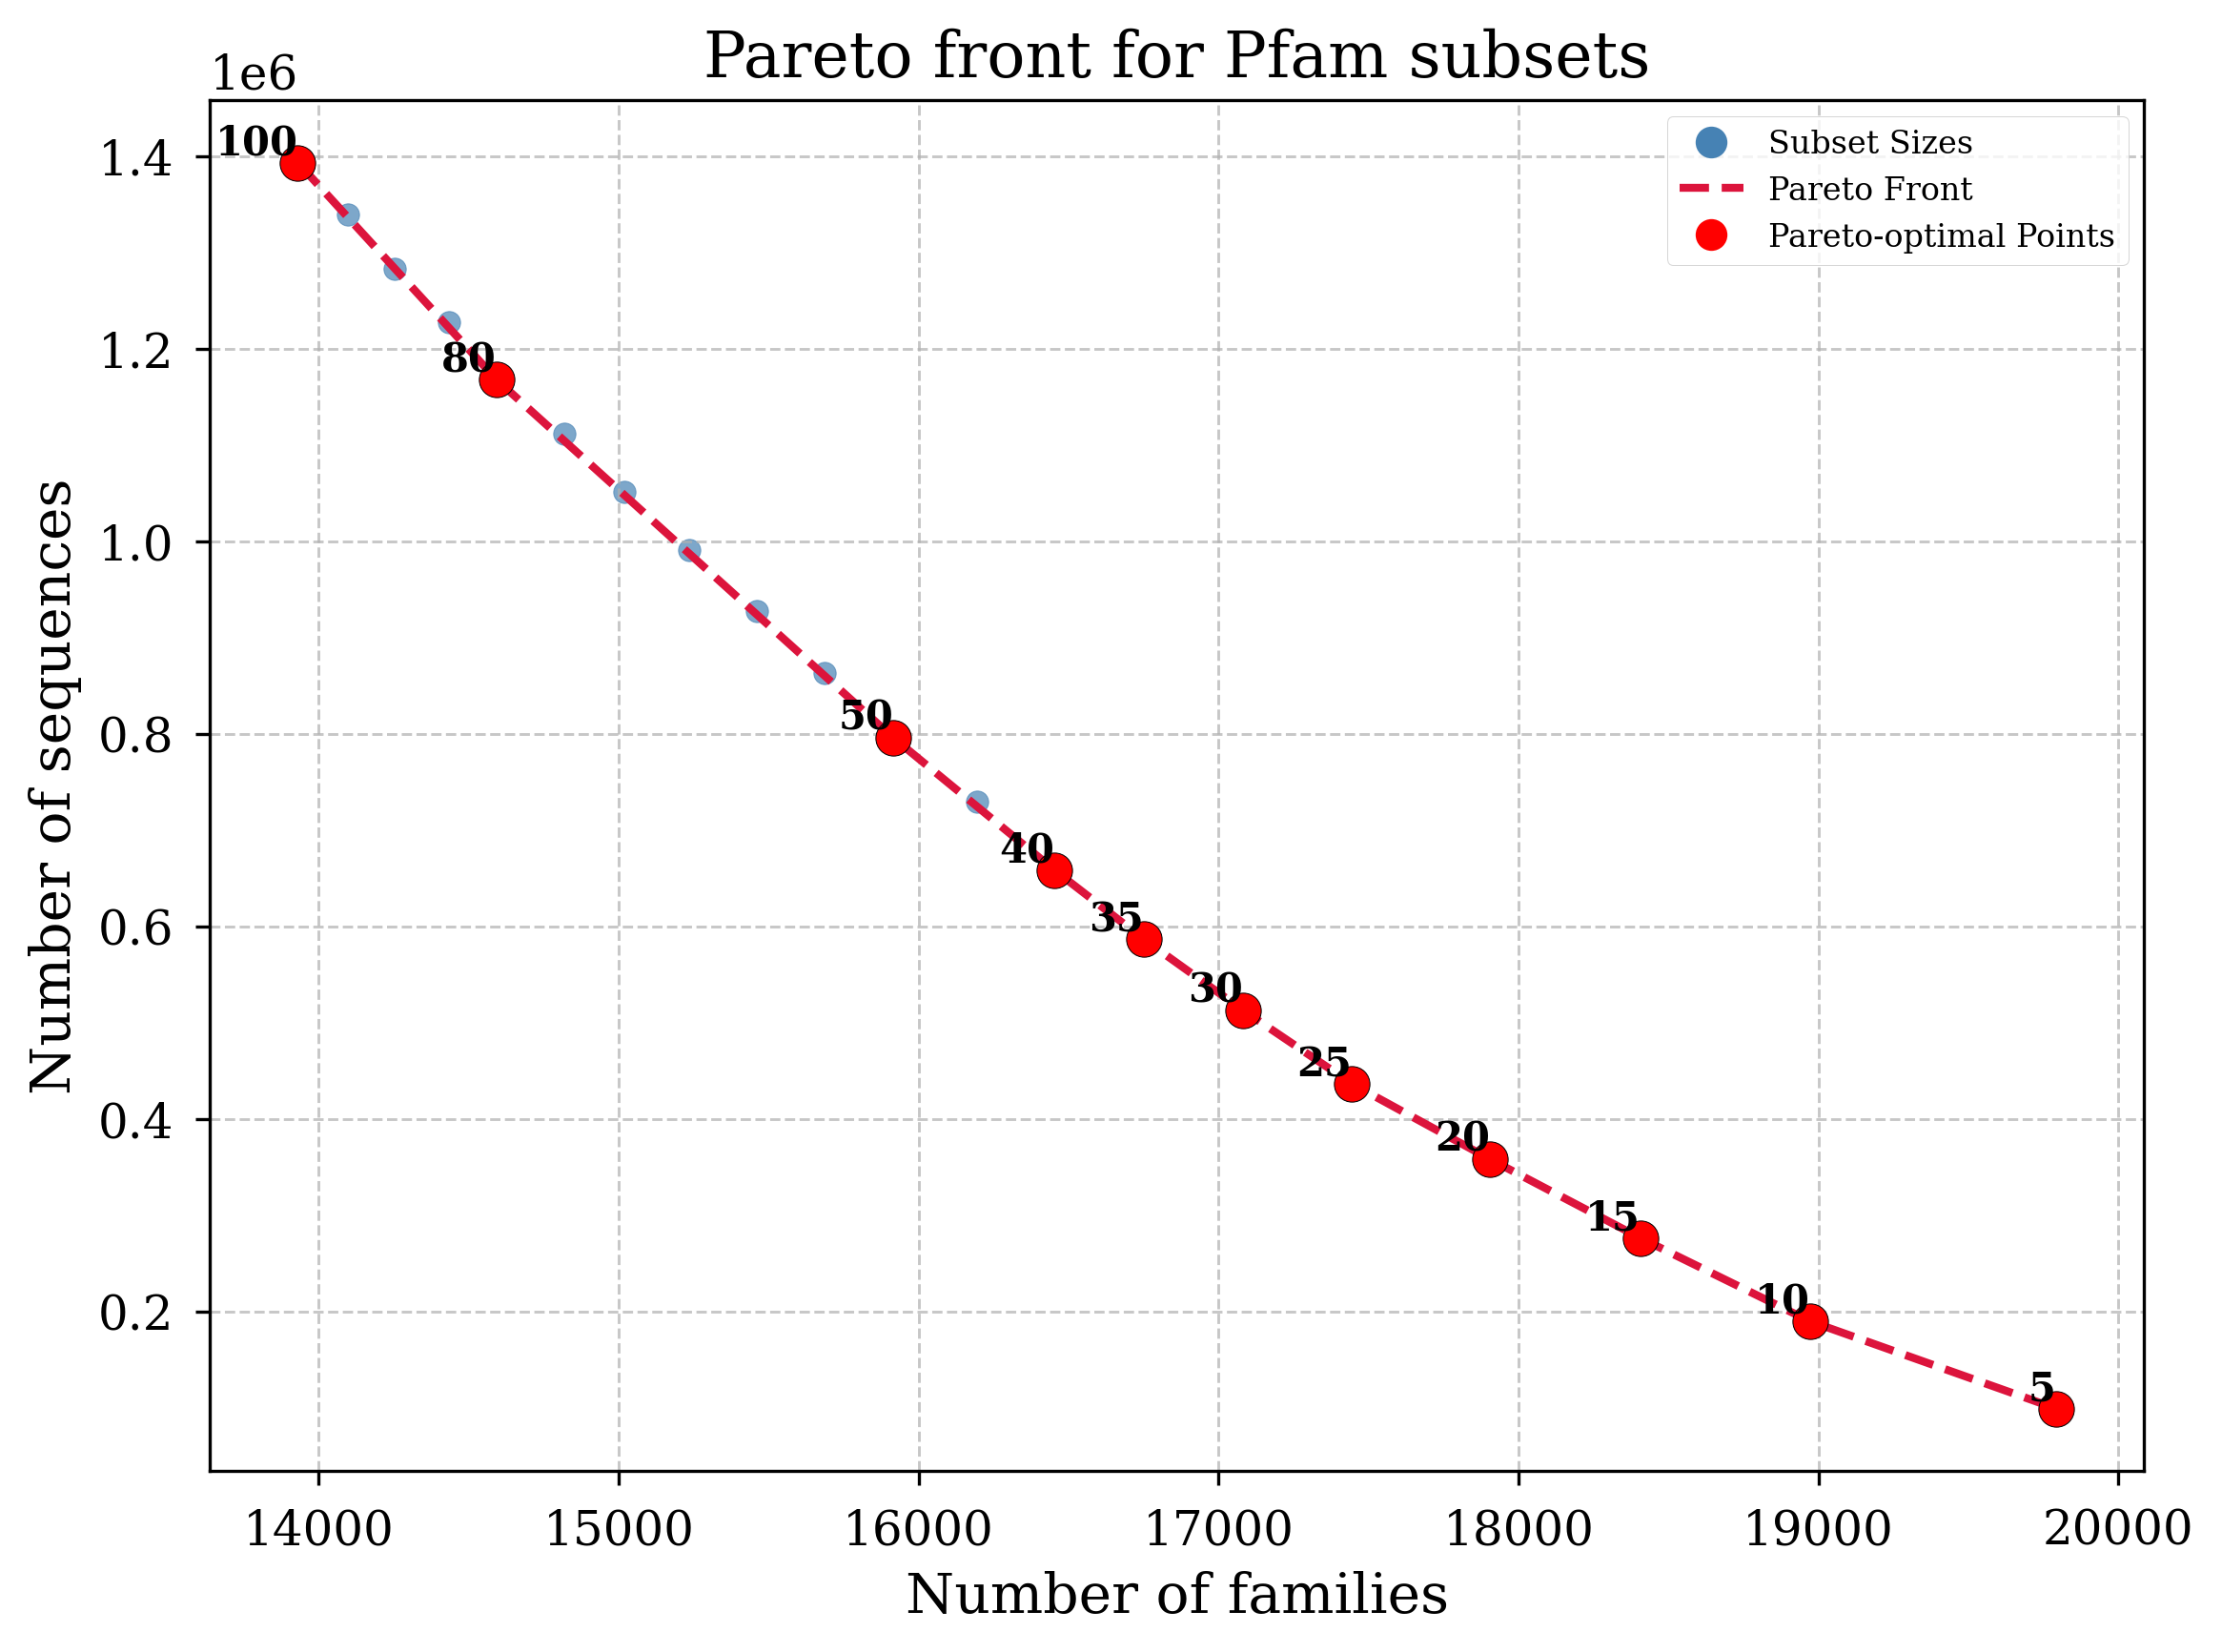

In [52]:
plot_pareto_front(
    subset_sizes=subset_sizes,
    num_families=num_families,
    num_sequences=num_sequences,
    xlabel="Number of families",
    ylabel="Number of sequences",
    title="Pareto front for Pfam subsets",
)


# Load the sequences 

In [3]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')

In [4]:
sequences = dataset.load_sequences()

Loading Pfam20 families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/families.json
Building a set of the uniprot IDs in the Pfam20 families...


Parsing Pfam sequences: 163028696it [02:40, 1016663.89it/s]


Saving Pfam20 with 358080 sequences to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/sequences.fasta


# Dataset statistics

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histogram(
    data: list[float | int],
    xlabel: str,
    ylabel: str,
    title: str = "",
    bins: int | None = None,
    save_path: str | None = None
) -> None:
    """Plot a histogram with automatically computed number of bins.

    Parameters
    ----------
    data : list[float | int]
        Data to plot in the histogram.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    title : str, optional
        Title of the plot, by default "" (no title).
    bins : int | None, optional
        The number of bins to use.
    save_path : str | None, optional
        If provided, saves the figure to the given path, by default None.
    
    Returns
    -------
    None
    """
    # High-quality publication settings
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
    })

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the histogram
    ax.hist(data, bins=bins, color='steelblue', edgecolor='black', alpha=0.7)

    # Customize the plot
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

    # Optimize layout
    plt.tight_layout()

    # Save if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # Show the plot
    plt.show()


In [4]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')
sequences = dataset.load_sequences()

Loading Pfam20 families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/sequences.fasta


In [6]:
# Compute the sequence lengths
sequence_lengths = [len(x.sequence) for x in sequences]

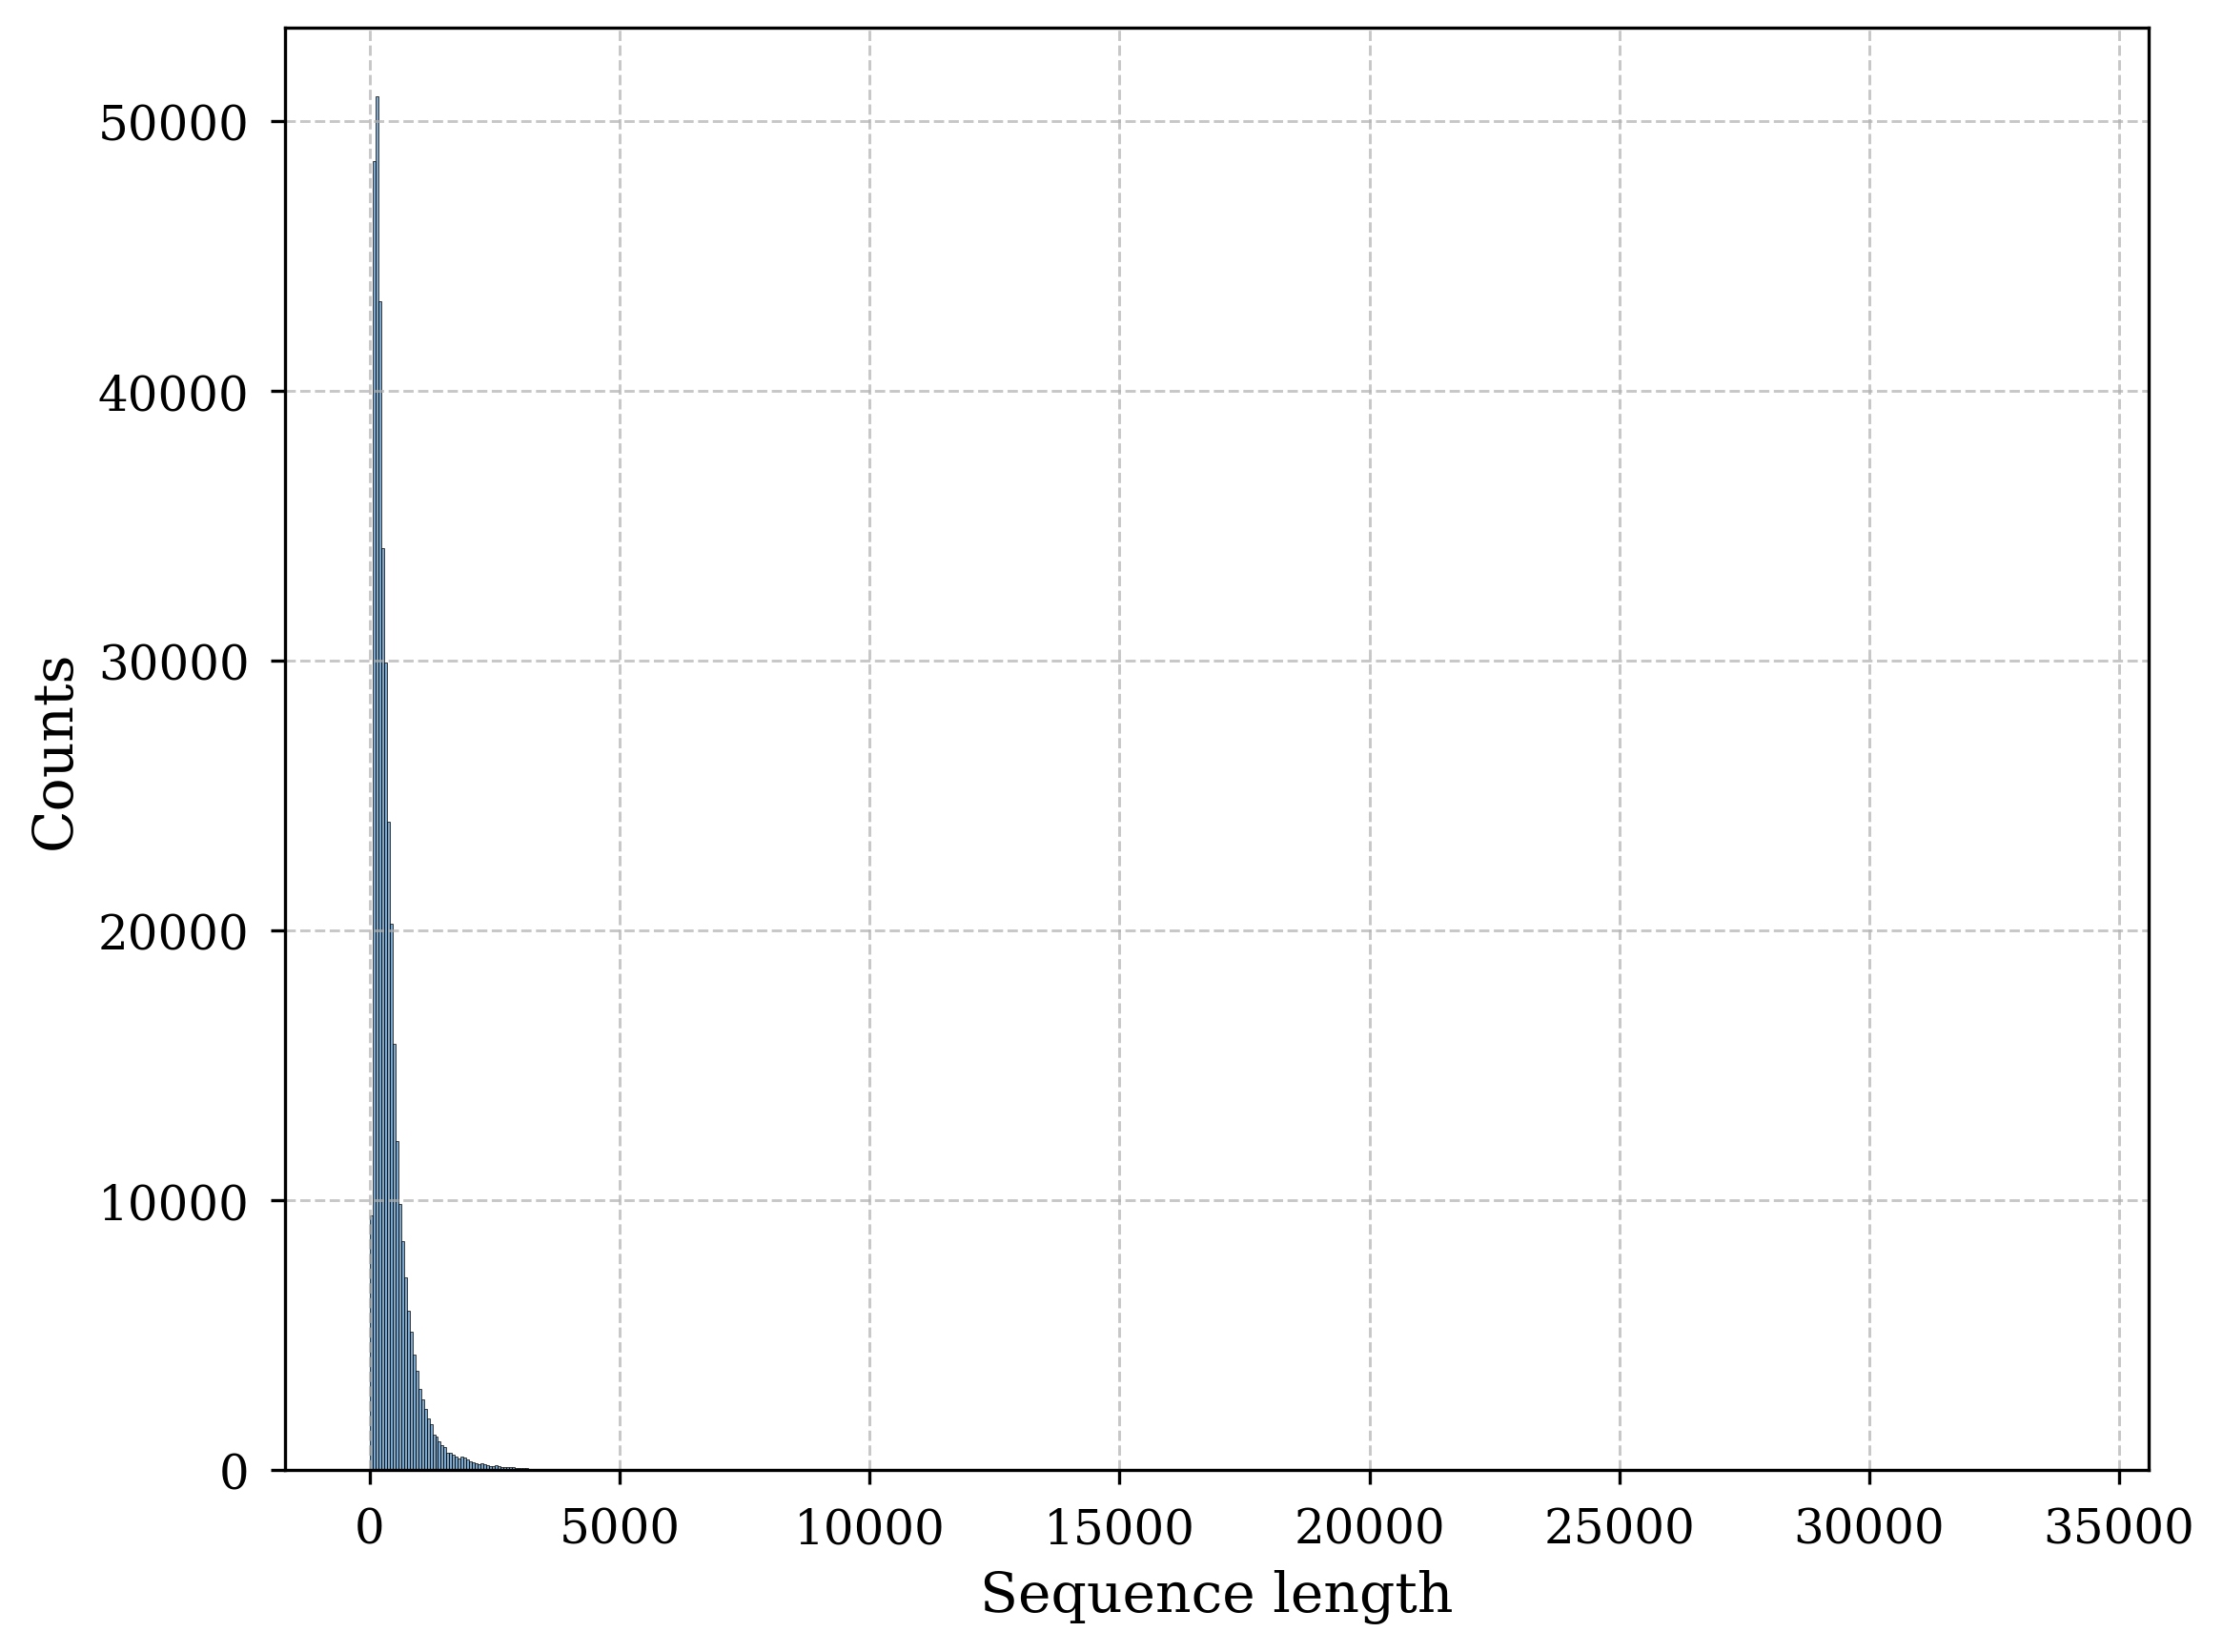

In [11]:
plot_histogram(sequence_lengths, xlabel="Sequence length", ylabel='Counts')

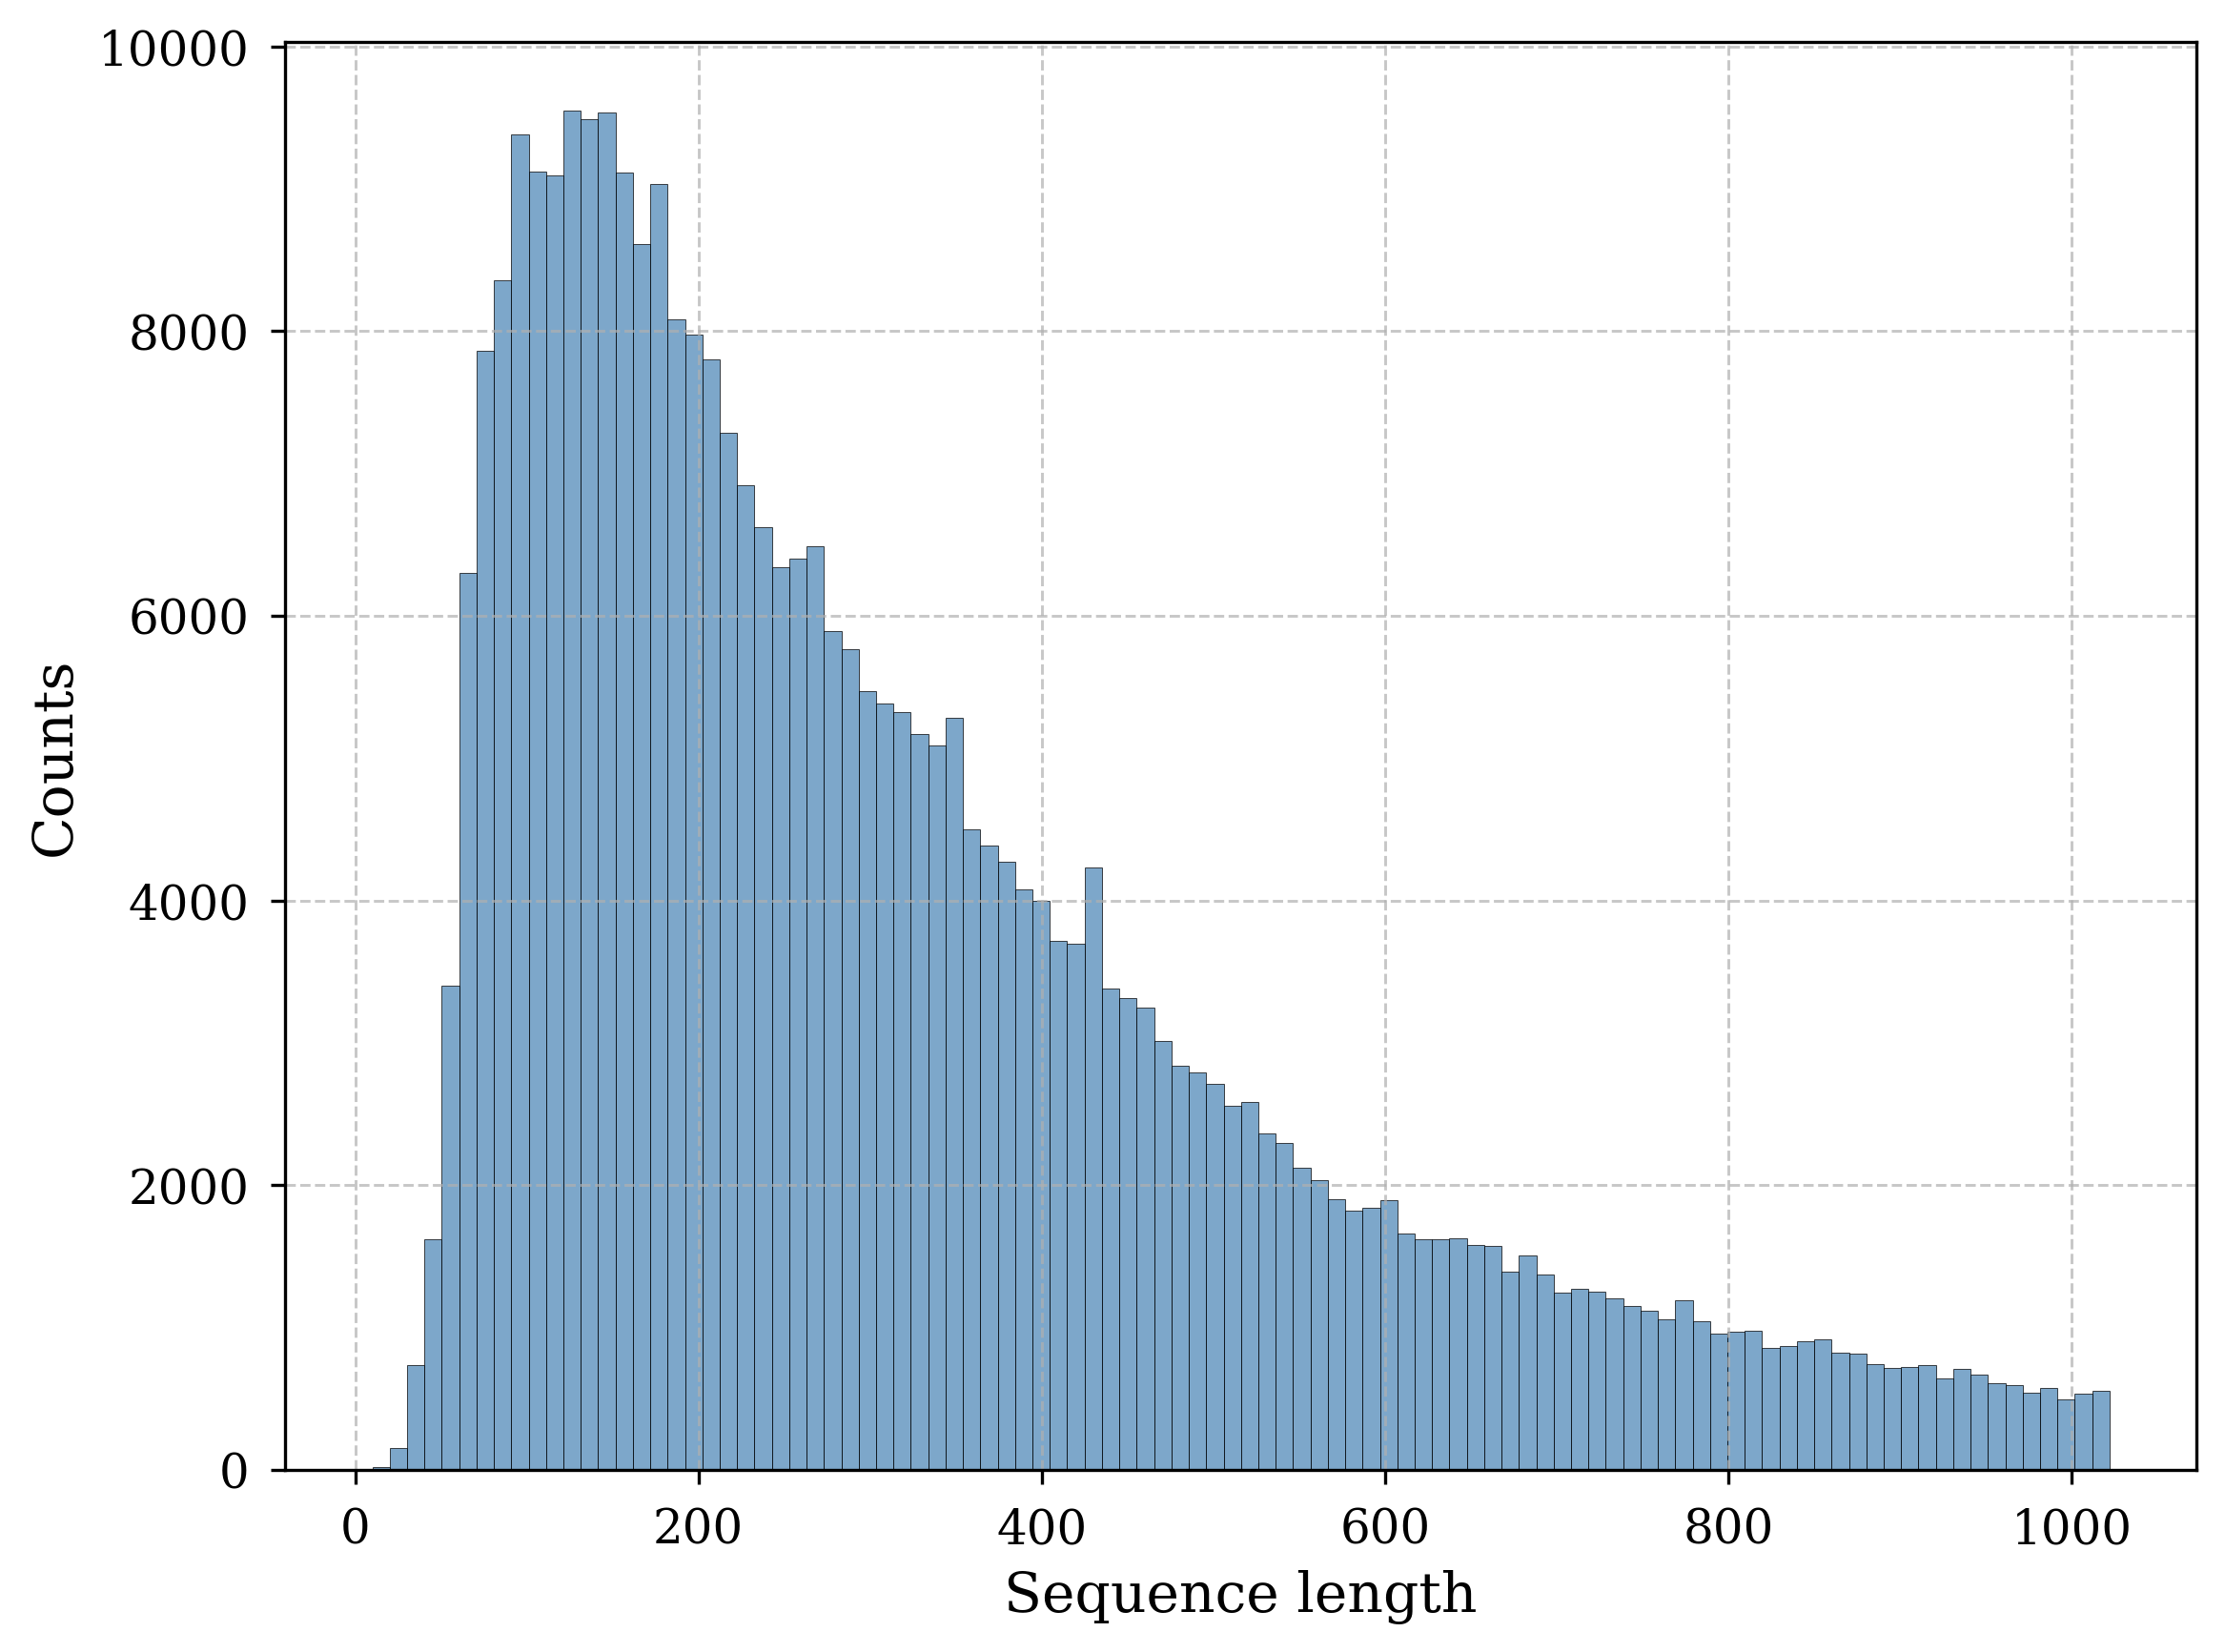

In [35]:
plot_histogram([x for x in sequence_lengths if x <= 1022], bins=100, xlabel="Sequence length", ylabel='Counts')

In [5]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')
sequences = dataset.load_sequences()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json
Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing sequences longer than 1022 residues...
	Num. sequences before size filtering: 27875440


Parsing Pfam sequence lengths: 163028696it [18:50, 144237.28it/s]


	Num. families after size filtering: 27078555
Removing families with less than 20 members...
	Num. families before size filtering: 21845
	Num. families after size filtering: 17599
Randomly selecting 20 domains (Uniprot IDs) from each family to balance the dataset using random seed: 42...
	Num. Uniprot IDs before filtering: 27052745
	Num. Uniprot IDs after filtering: 351980
Saving Pfam20 families metadata to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/families.json
Building a set of the uniprot IDs for the selected Pfam20 families...


Parsing Pfam sequences: 163028696it [07:45, 350524.22it/s]


Saving Pfam20 with 351980 sequences to /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/sequences.fasta


In [6]:
sequence_lengths = [len(x.sequence) for x in sequences]

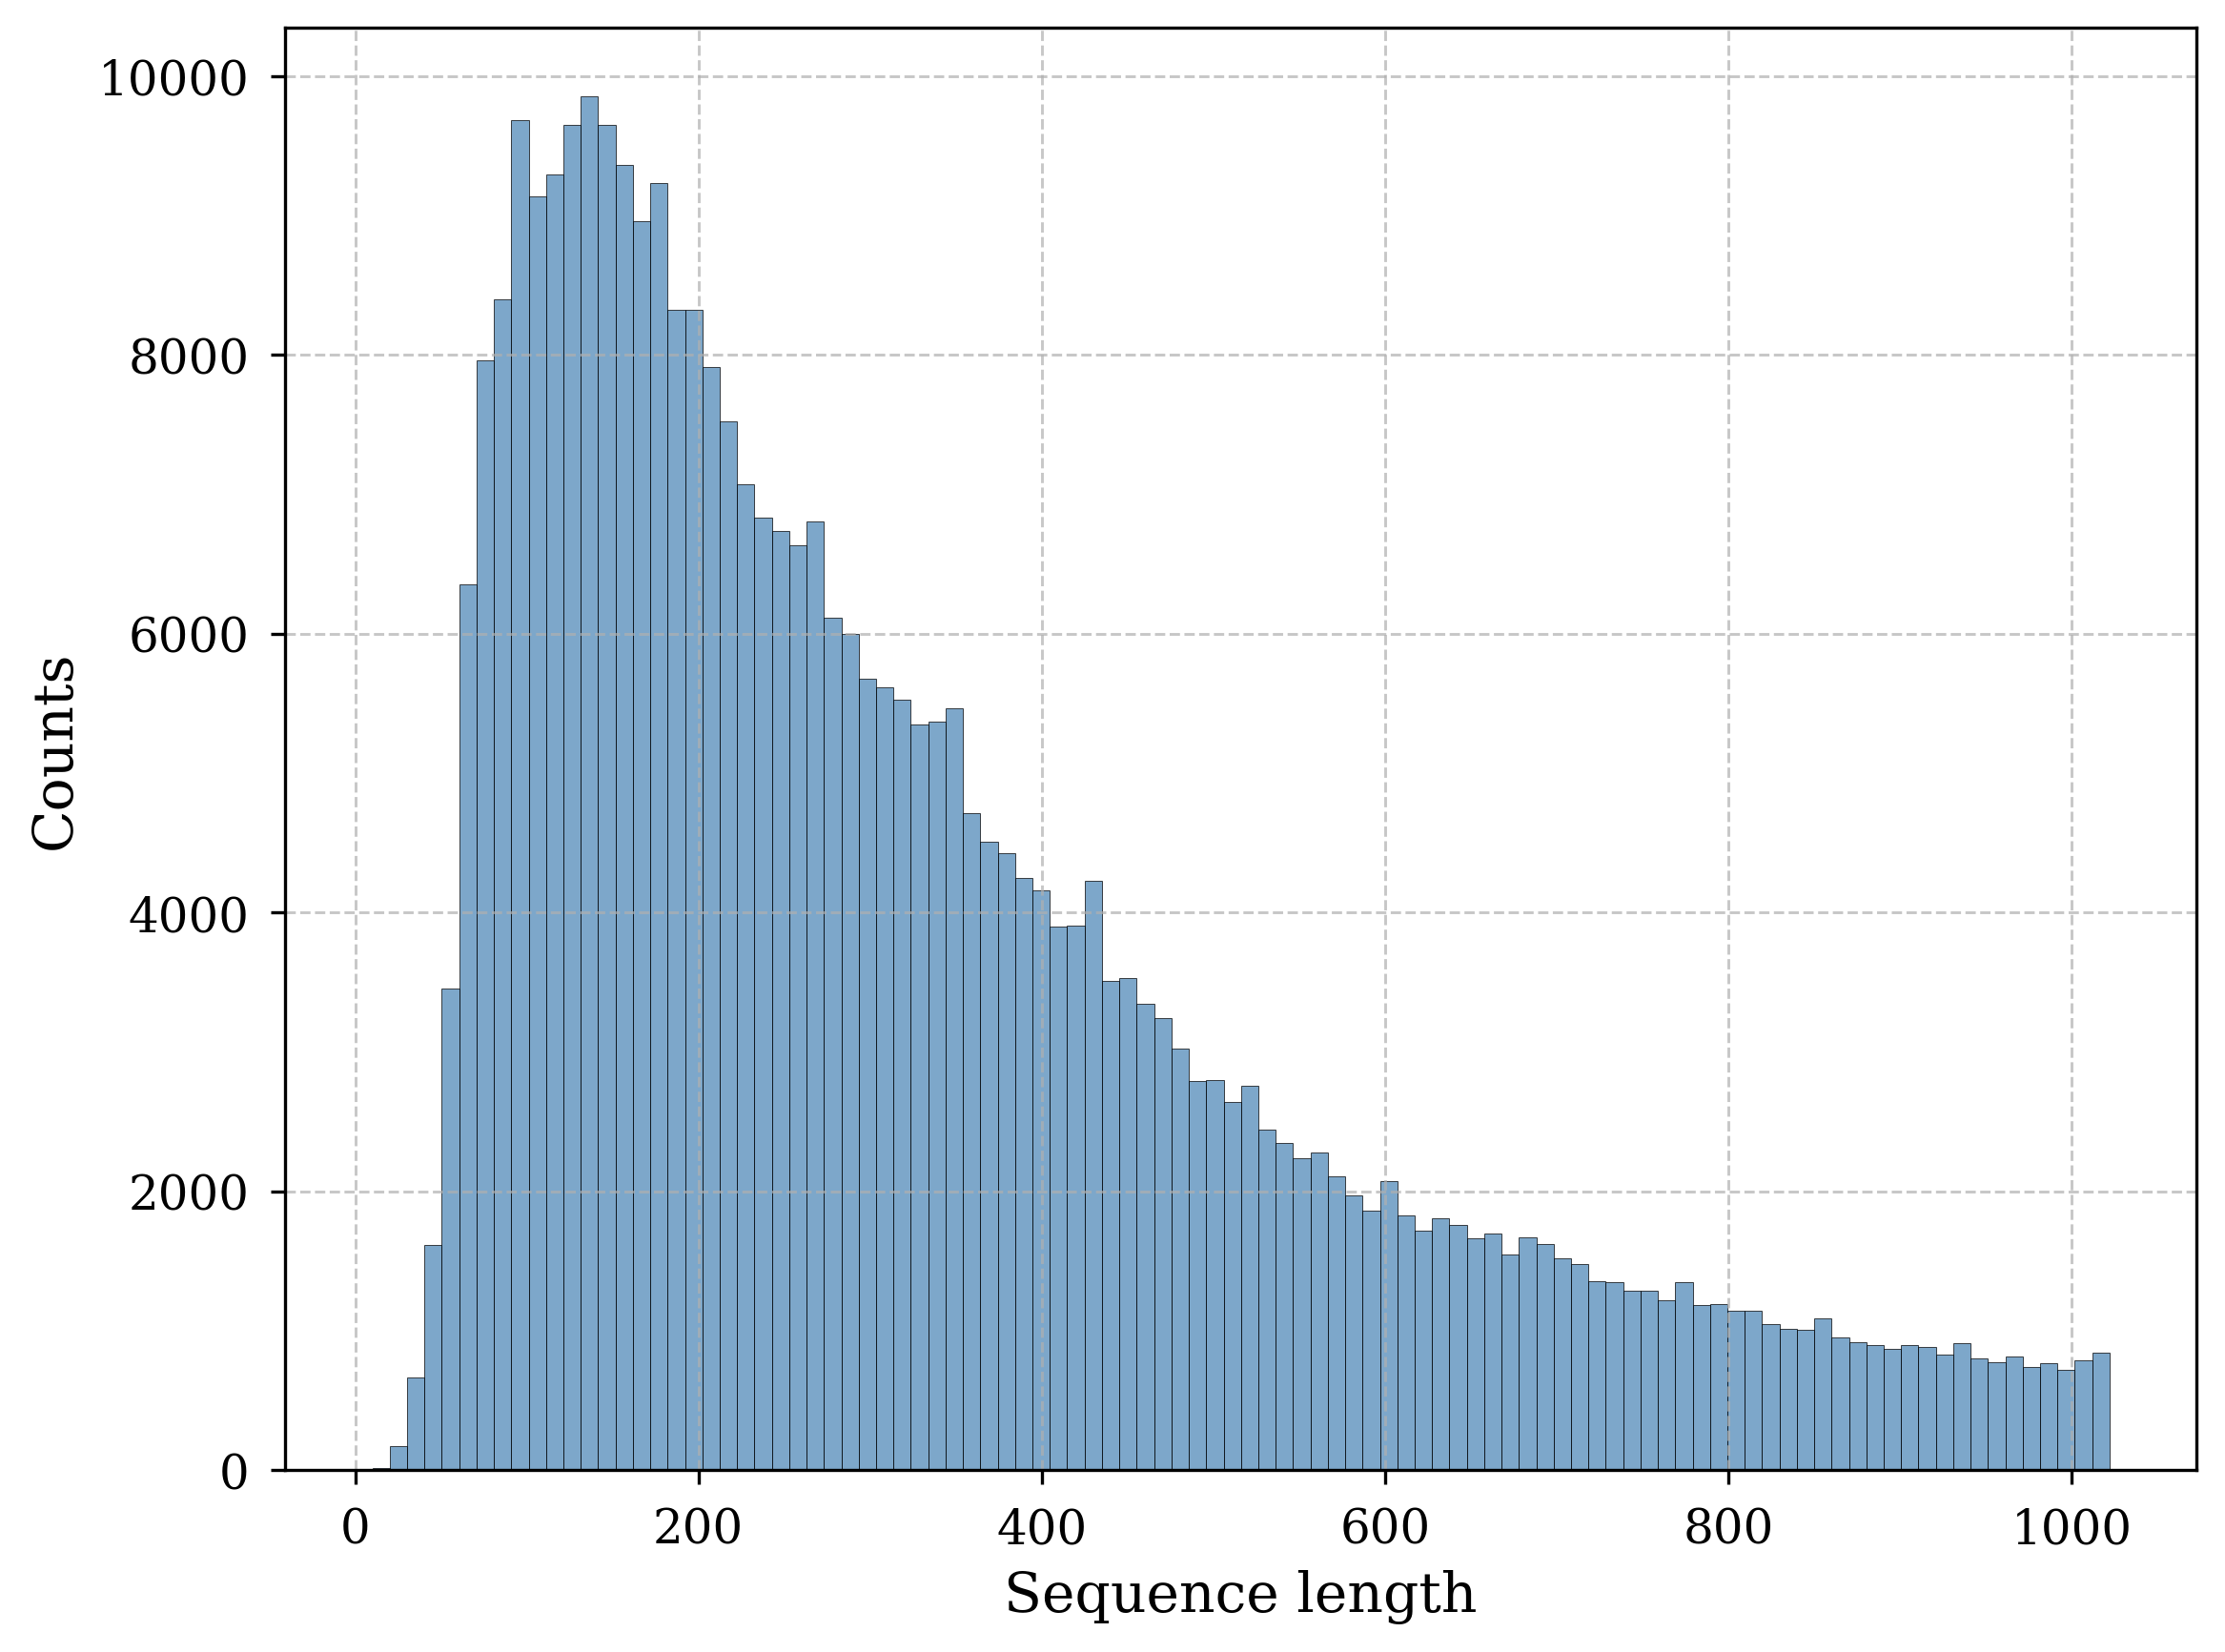

In [9]:
plot_histogram(sequence_lengths, bins=100, xlabel="Sequence length", ylabel='Counts')

# See what Uniprot IDs map into CDS sequences

In [3]:
dataset = Pfam20Dataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')
sequences = dataset.load_sequences()

Loading Pfam20 families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/sequences.fasta


In [7]:
!head /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/sequences.fasta

>A0A8J7XFM5.1
MRVPVGQKIRDLELTEPRVTILIDEAEKENLTGFVRVTYEKKGINDFYIFFINGTLVGIYGEEMLTEKEVFGKEALDHALAIFSSGLAGLYSLDGEDVQSLGEEEPLLLLEKKELGFTELLEAQLRNLNEDGQFMASLVADVQGLPVAAMDSEYQNERIAALSALVRDVSHRAETQLGFKKTDEVSLVDDDKVRLVCRYFQVGDQTYILSCVVPAYQPYRRLTNTALREIEKIMKQRFS
>A0A8J7XWP0.1
MFDYIFHAVEKEISGQNAKNLAHEVTRFHRIQVSPHFREAALWCCNQLKEWGLDCHVCEFPADGRTMYWSYLLPDEWKVDSAVLEIEGKIWADFRDEKVSLIQRSHPVAVEAEIVHIDGDDEKDFQNIKGKIIHSPLSLEKIKDLALHYGAAGILTSGIREISERTRIDVPDAVHYFSFWGEKASGFVLSPRKGEALRKMVRETKSVKGRMTIESSLYPGAMEVVDAVIPGESDEEVLVVAHLCHPQPSANDNASGDGALMEVARALKHLIDENKLKNPRRSIRFLLVPEIHGTVAYLASHEKDLPGMVAALNLDMVGETQEVCNSTLLLERTPHAMPSFVNDLAEVIFEKLTHEIGNFSGSTKYATFRHAVTPFSGGSDHLVLSDPTVGVPCPMIIQWPDMFYHSSLDTIDKIDPASMKRVSILTATYAYFIAAAGEEEAQWLAFIVMEKAKERIIRKGREIVTILADEELKKHGTDKKKQKDGKGRGIEGEKERDATWDYVGQLDYLLDREIHAIRSVKTLAEIDTEPLENELKQVVSAEKERVKQYESAPEKENQEECTWVPVRVYPGPISTRKVLLDMSFEQRRAFEKKQEGVKASRLLETLAVYWSDGERTLSEINRLLTYEIGQSSLEFLKWYFGFLEEHGLVELRR
>A0A8J8BSV7.1
MVLVLQAETKVVSQTVVHYSGLHAAVLVLLVLAAFRITKLFTPPEEVPTEKPQLEKGTMYLVKG

In [8]:
import datasets

cds_dataset_path = '/nfs/lambda_stor_01/homes/khippe/genslm_foundation/downstream_evaluation/uniprot/embl-cds-uniprot.hf'
d = datasets.load_from_disk(cds_dataset_path)

Loading dataset from disk:   0%|          | 0/54 [00:00<?, ?it/s]

In [10]:
cds_uniprot_ids = set(d['uniprot_id'])

In [11]:
for i in cds_uniprot_ids:
    print(i)
    break

A0A151WYN3


In [13]:
pfam_uniprot_ids = set([seq.tag.split('.')[0] for seq in sequences])

In [14]:
for i in pfam_uniprot_ids:
    print(i)
    break

A0A671NC53


In [16]:
overlap = pfam_uniprot_ids.intersection(cds_uniprot_ids)

In [17]:
len(overlap)

29713

In [19]:
len(sequences)

351980

In [20]:
families = dataset.load_families()

Loading Pfam20 families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfam20_seed-42/families.json


In [28]:
from tqdm import tqdm
from collections import defaultdict

In [27]:
families_nodots = {pfam_id: set([x.split('.')[0] for x in uniprot_ids]) for pfam_id, uniprot_ids in families.items()}

In [31]:
cds_family_distribution = {
    pfam_id: list(uniprot_ids.intersection(overlap))
    for pfam_id, uniprot_ids in tqdm(families_nodots.items())
}

100%|██████████████████████████████████████████████████████| 17599/17599 [00:00<00:00, 302732.45it/s]


In [34]:
sequences_per_family = [len(uniprot_ids) for uniprot_ids in cds_family_distribution.values()]

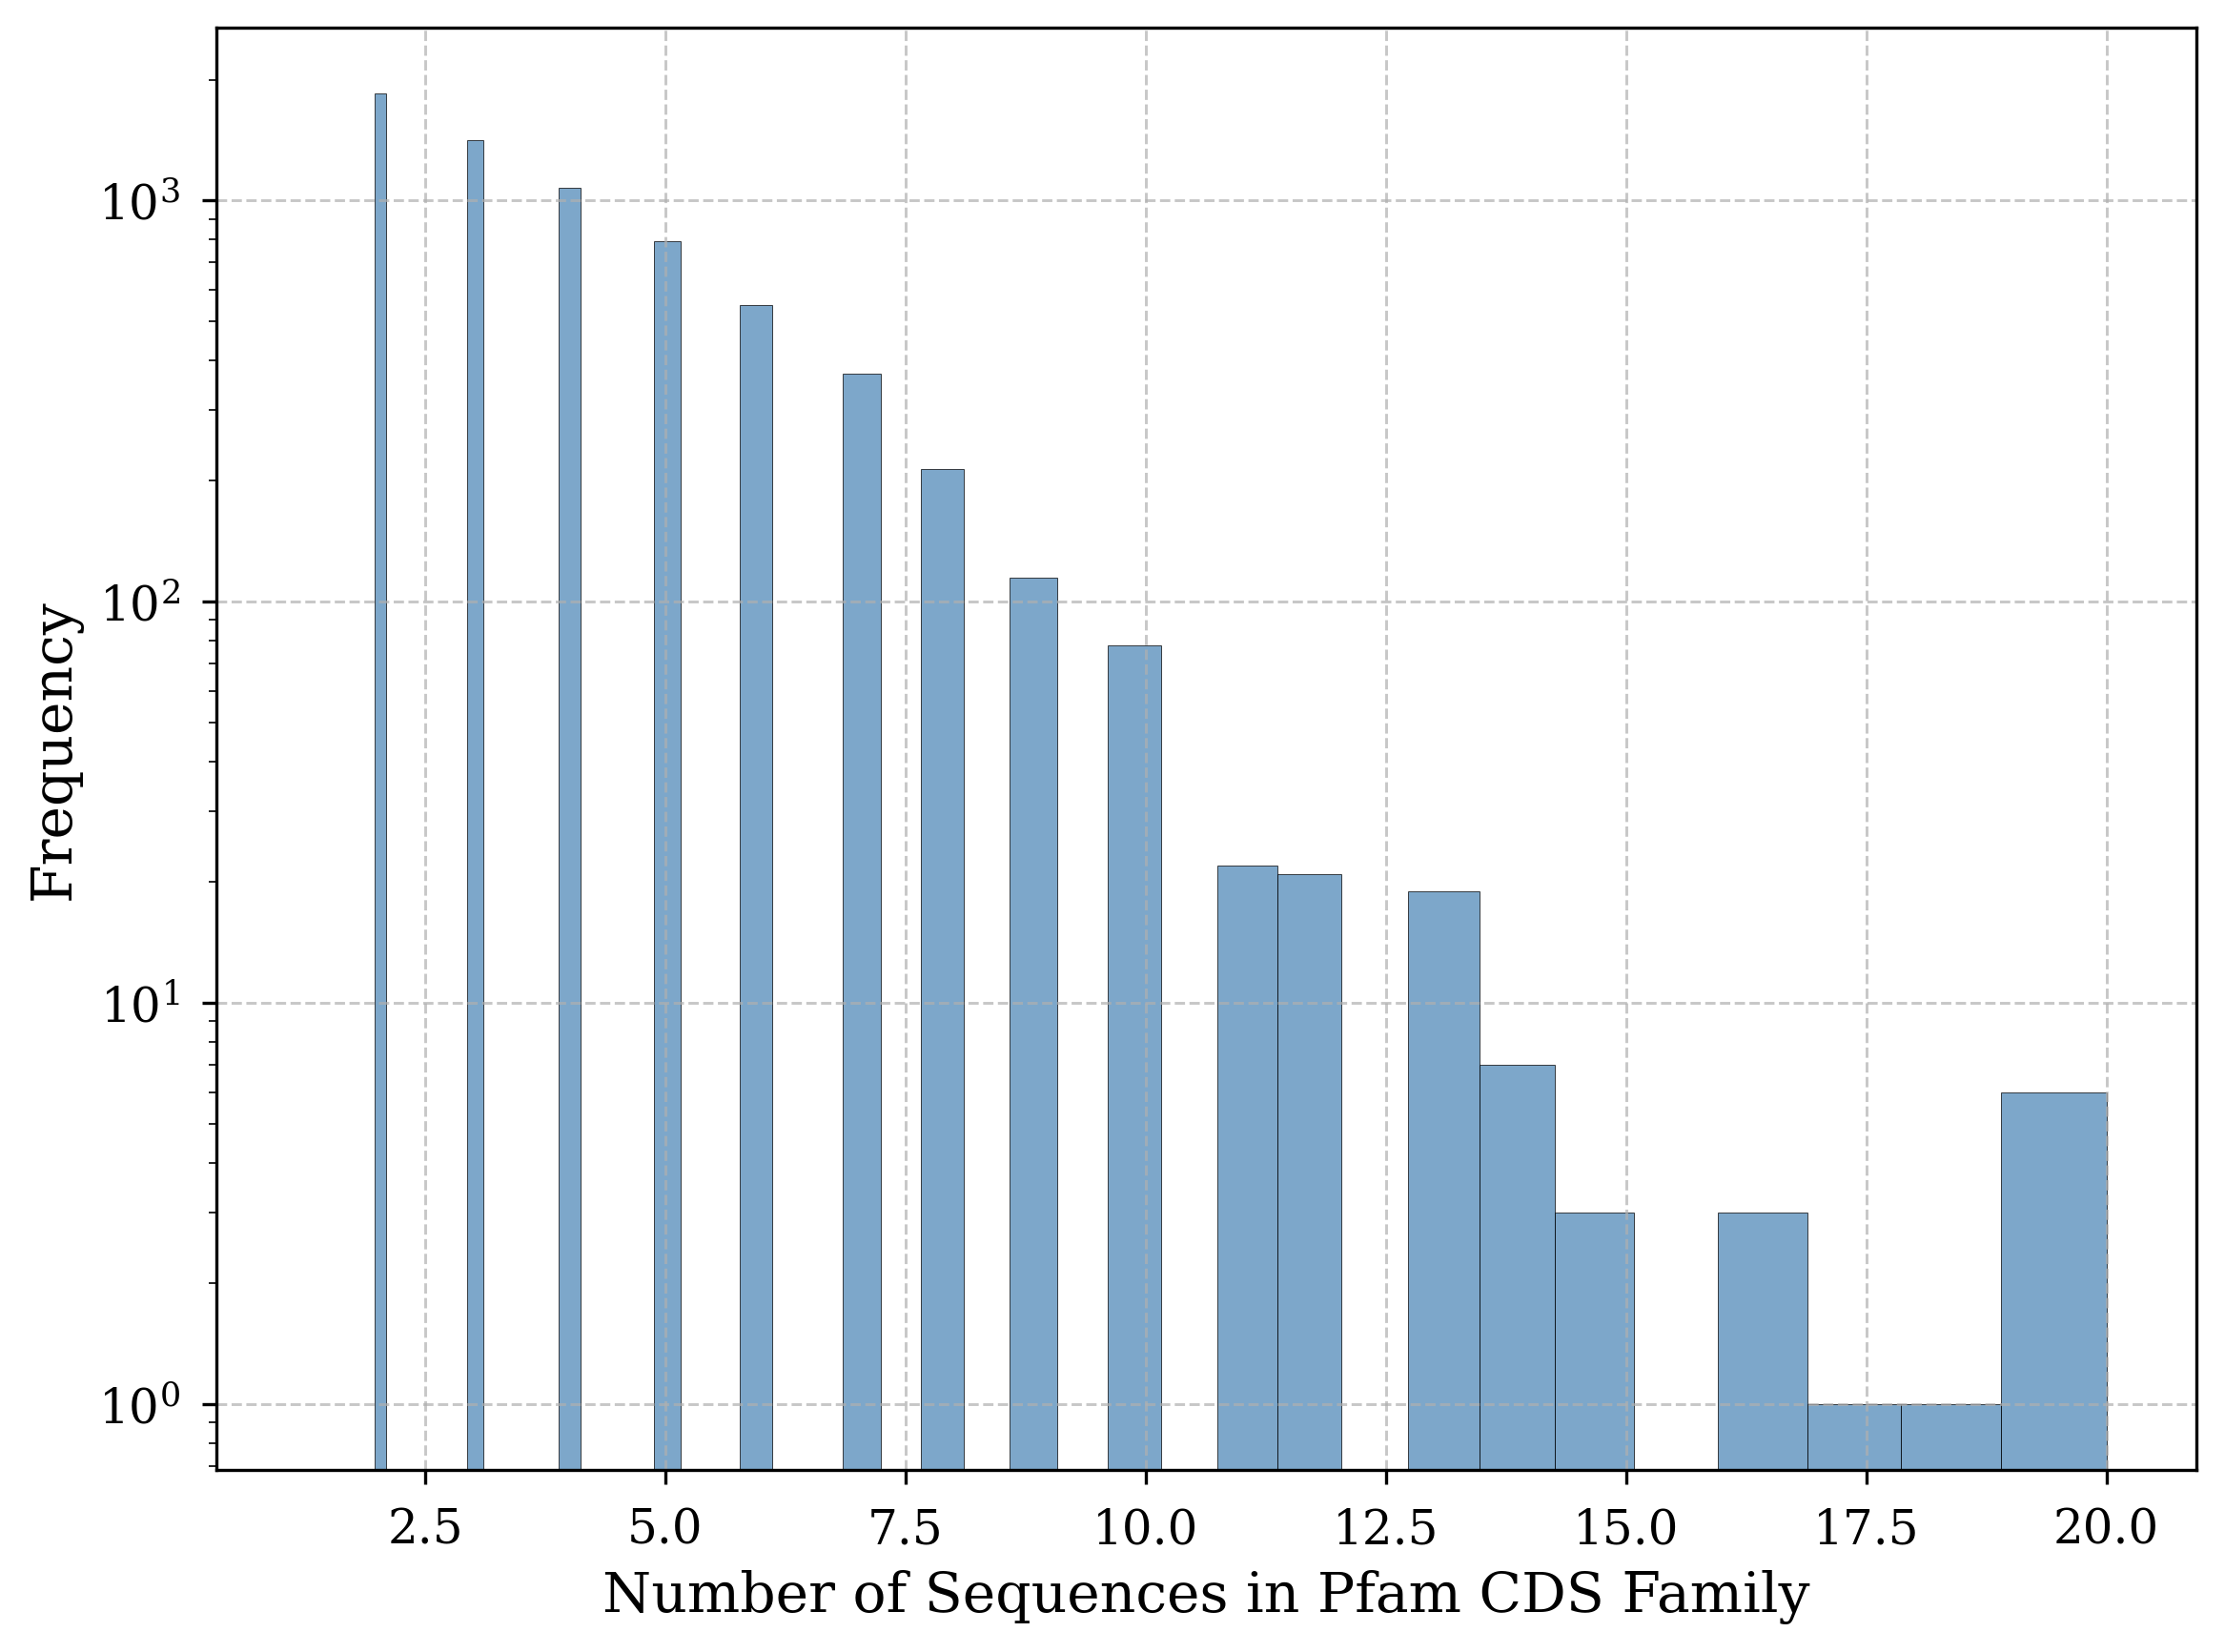

In [35]:
plot_histogram(sequences_per_family, xlabel="Number of Sequences in Pfam CDS Family")

In [37]:
sequences_per_family.count(0) / len(sequences_per_family) # percent of families with representatives

0.45604863912722315

In [38]:
sequences_per_family.count(0) # number of families with representatives

8026

# See how many sequences are in the full Pfam

In [40]:
dataset = PfamDataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')
families = dataset.load_families()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json


In [43]:
import datasets

cds_dataset_path = '/nfs/lambda_stor_01/homes/khippe/genslm_foundation/downstream_evaluation/uniprot/embl-cds-uniprot.hf'
d = datasets.load_from_disk(cds_dataset_path)
cds_uniprot_ids = set(d['uniprot_id'])

Loading dataset from disk:   0%|          | 0/54 [00:00<?, ?it/s]

In [47]:
pfam_uniprot_ids = {uid.split('.')[0] for uids in families.values() for uid in uids}

In [49]:
overlap = pfam_uniprot_ids.intersection(cds_uniprot_ids)

In [50]:
len(overlap)

2947649

In [51]:
families_nodots = {pfam_id: set([x.split('.')[0] for x in uniprot_ids]) for pfam_id, uniprot_ids in families.items()}

In [52]:
cds_family_distribution = {
    pfam_id: list(uniprot_ids.intersection(overlap))
    for pfam_id, uniprot_ids in families_nodots.items()
}

In [53]:
sequences_per_family = [len(uniprot_ids) for uniprot_ids in cds_family_distribution.values()]

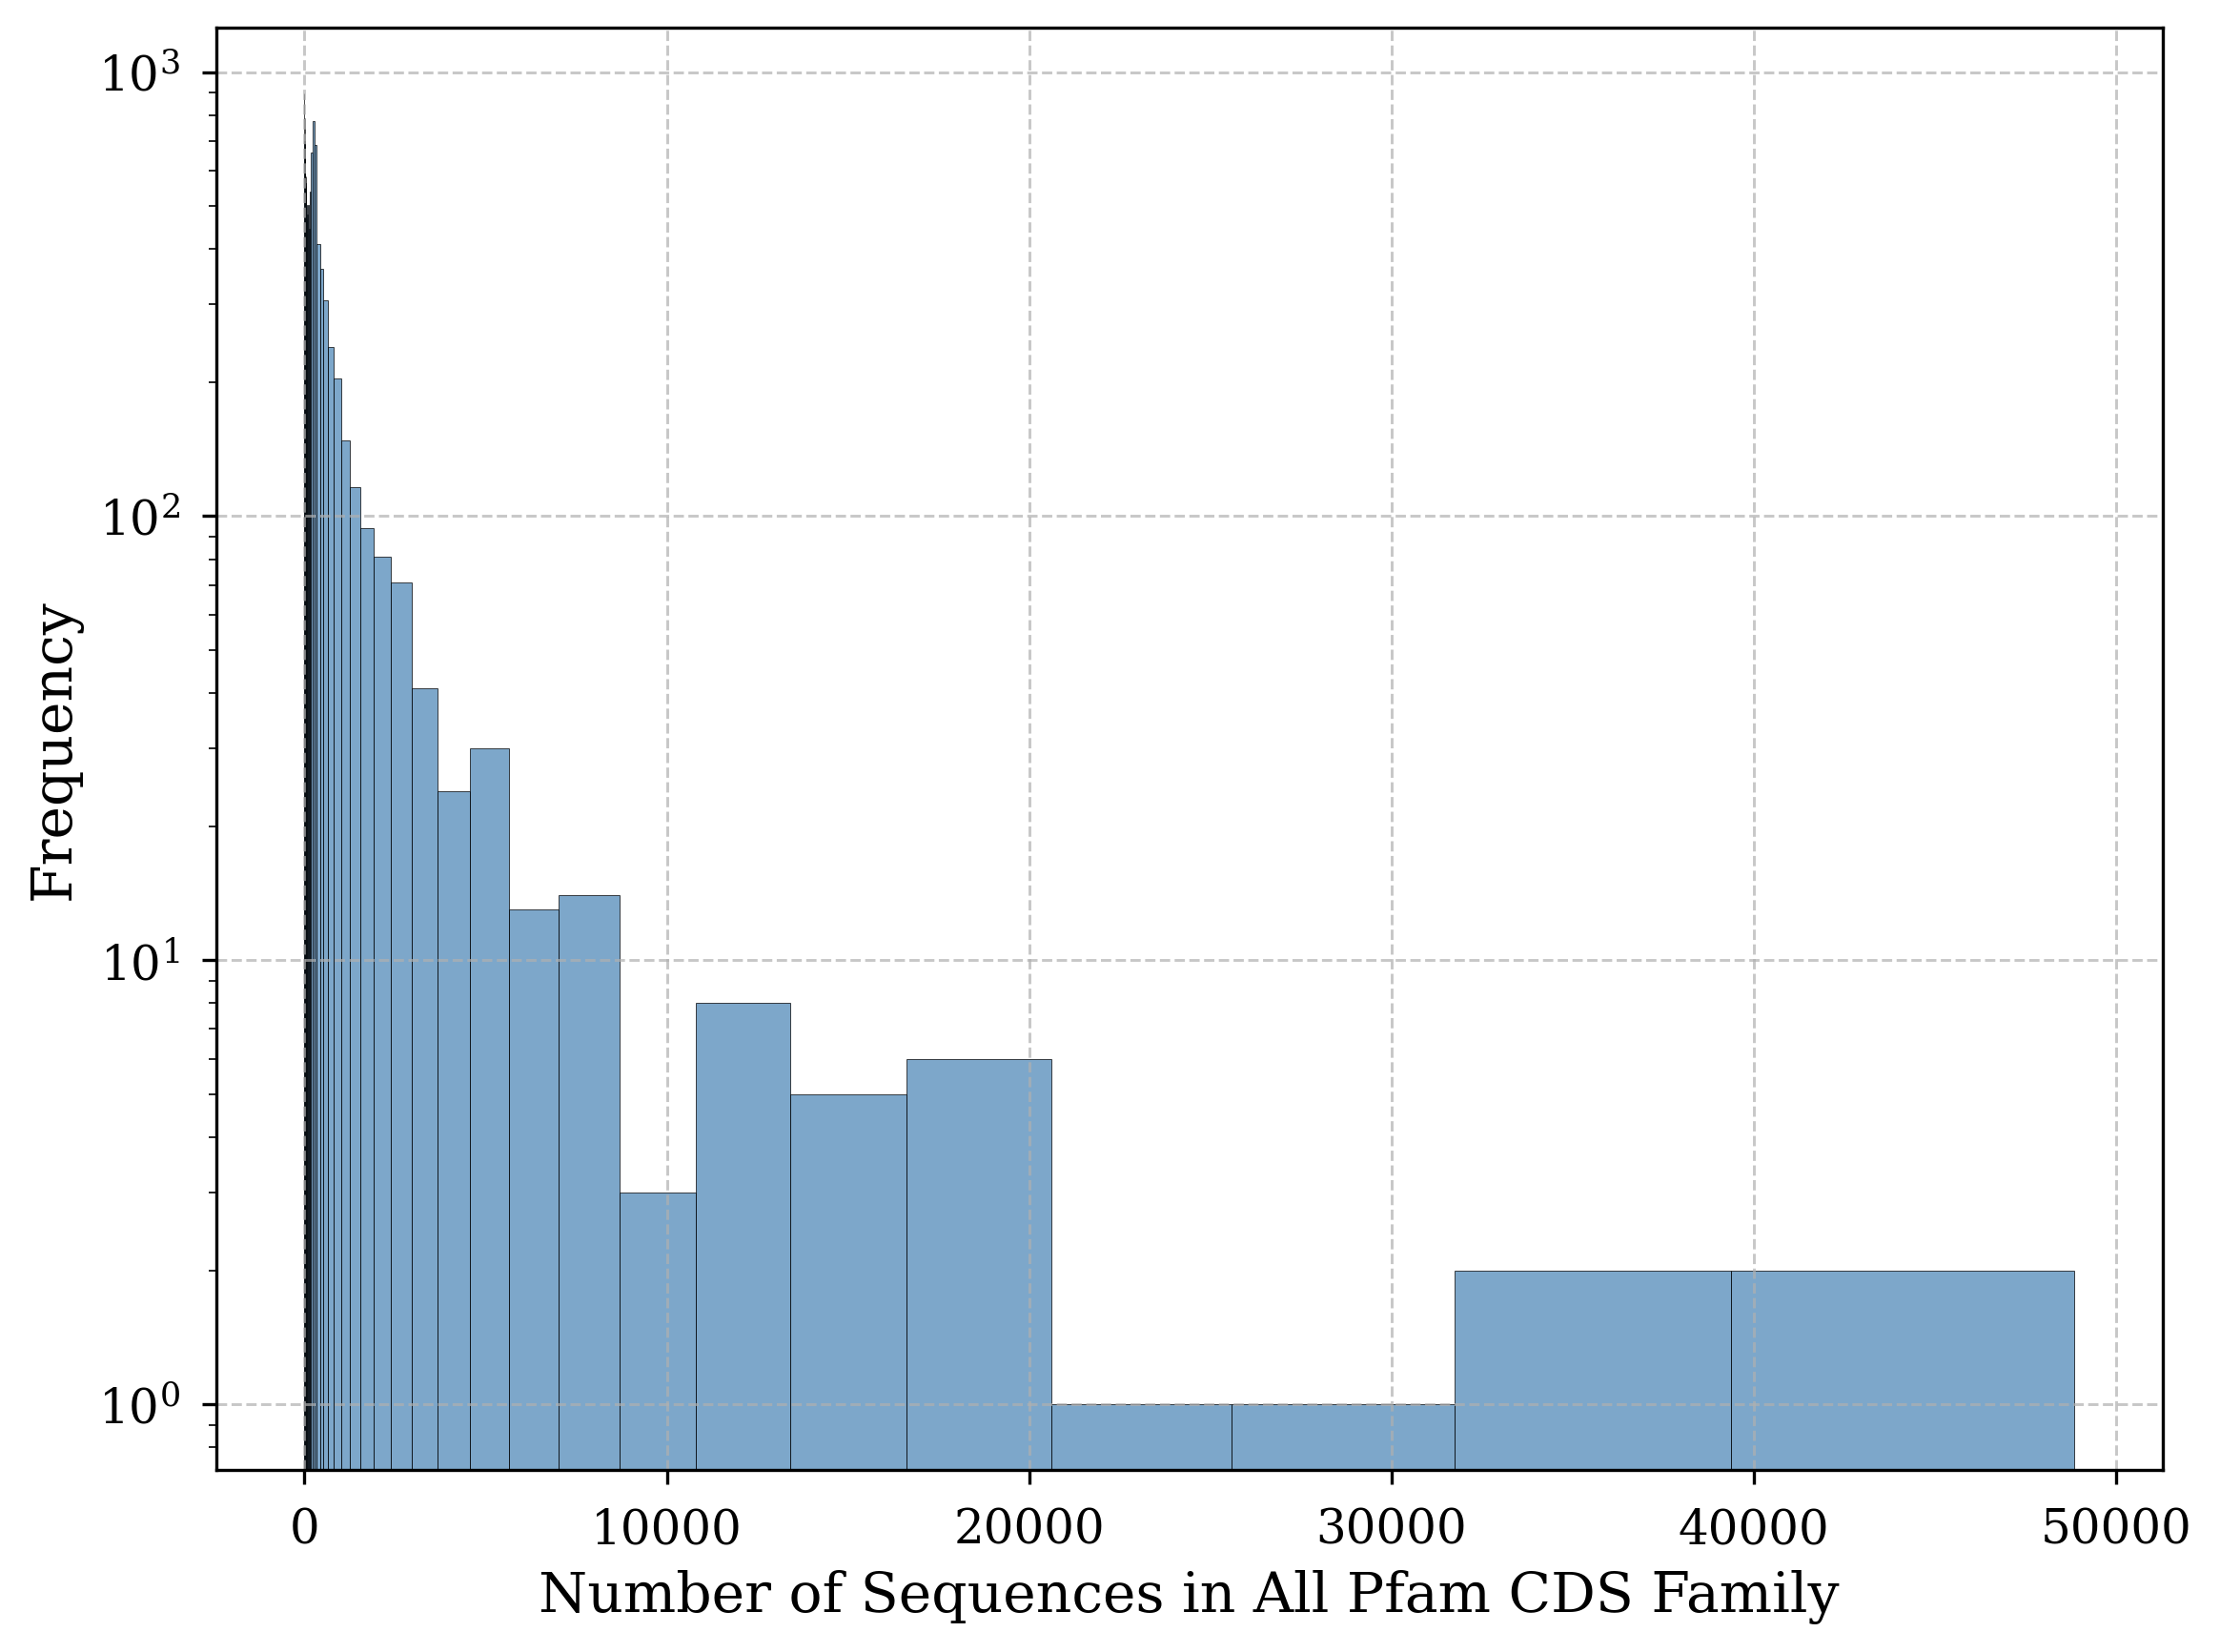

In [54]:
plot_histogram(sequences_per_family, xlabel="Number of Sequences in All Pfam CDS Family")

# Apply some filtering for sequence quality

In [60]:
from collections import Counter

def load_uniprot_ids_by_length(length_cutoff: int) -> set[str]:
    """Load the UniProt IDs for sequences that meet the length cutoff.

    Parameters
    ----------
    length_cutoff : int
        The maximum length of the sequences to include in the dataset.

    Returns
    -------
    set[str]
        A set of UniProt IDs for the sequences that meet the length cutoff.
    """
    # The file is a bit large to load all the sequences at once
    # so we iterate over the file and collect the UniProt IDs
    # that meet the length cutoff
    uniprot_ids = []
    with open('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/pfamseq') as file:
        # Initialize the sequence buffer and the current UniProt ID
        uid: str | None = None
        seq: list[str] = []

        for line in tqdm(file, desc='Parsing Pfam sequence lengths'):
            # Remove leading/trailing whitespace
            contents = line.strip()

            # If we are starting a new entry, collect the previous entry
            # and reset the sequence buffer
            if contents.startswith('>'):
                # Collect the previous entry
                if uid is not None and len(''.join(seq)) <= length_cutoff:
                    uniprot_ids.append(uid)

                # Extract UniProt ID from the header
                # (assuming format ">uniprot_id uniprot_name description")
                parts = contents.split(' ')

                # Remove '>' from the first part
                uid = parts[0][1:] if parts else None

                # Reset sequence buffer
                seq = []
            else:
                # Append the sequence contents
                seq.append(contents)

        # Capture last entry
        if uid is not None and len(''.join(seq)) <= length_cutoff:
            uniprot_ids.append(uid)

    return set(uniprot_ids)

def _filter_by_uniprot_ids(
    families: dict[str, list[str]],
) -> dict[str, list[str]]:
    print('Removing uniprot IDs that appear in more than one family...')

    # Count the number of occurrences of each uniprot ID across families
    # A dictionary with the form {uniprot_id: count across families}
    uniprot_counts = Counter(chain.from_iterable(families.values()))
    print(f'\tNum. IDs before filtering: {len(uniprot_counts)}')

    # A set of unique uniprot IDs that appear in only one family
    unique_uniprot_ids = {k for k, v in uniprot_counts.items() if v == 1}

    # Remove uniprot IDs that appear in more than one family
    families = {
        pfam_id: [x for x in uniprot_ids if x in unique_uniprot_ids]
        for pfam_id, uniprot_ids in families.items()
    }

    print(f'\tNum. unique IDs after filtering: {len(unique_uniprot_ids)}')

    return families


def _filter_by_seq_length(
    families: dict[str, list[str]],
    length_cutoff: int,
) -> dict[str, list[str]]:
    print(f'Removing sequences longer than {length_cutoff} residues...')

    # Compute the number of sequences before size filtering
    num_sequences = sum(len(v) for v in families.values())
    print(f'\tNum. sequences before size filtering: {num_sequences}')

    # Load the sequence lengths for the Pfam sequences (this takes ~3 mins)
    valid_uids = load_uniprot_ids_by_length(length_cutoff)

    # Filter the families by the sequence lengths
    families = {
        pfam_id: [x for x in uniprot_ids if x in valid_uids]
        for pfam_id, uniprot_ids in families.items()
    }

    # Compute the number of sequences after size filtering
    num_sequences = sum(len(v) for v in families.values())
    print(f'\tNum. families after size filtering: {num_sequences}')

    return families

def _filter_by_family_size(
    families: dict[str, list[str]],
    subset_size: int,
) -> dict[str, list[str]]:
    print(f'Removing families with less than {subset_size} members...')
    print(f'\tNum. families before size filtering: {len(families)}')
    families = {k: v for k, v in families.items() if len(v) >= subset_size}
    print(f'\tNum. families after size filtering: {len(families)}')
    return families

In [58]:
dataset = PfamDataset('/lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam')
families = dataset.load_families()

Loading Pfam families metadata from /lambda_stor/homes/abrace/projects/kbase/src/protein_search_evals/data/pfam/families.json


In [61]:
# Filter the families by uniprot IDs to avoid multiple correct answers
families = _filter_by_uniprot_ids(families)

# Filter the families by the sequence lengths (we don't want very long
# sequences in the benchmark)
families = _filter_by_seq_length(families, length_cutoff=1022)

Removing uniprot IDs that appear in more than one family...
	Num. IDs before filtering: 38979839
	Num. unique IDs after filtering: 27875440
Removing sequences longer than 1022 residues...
	Num. sequences before size filtering: 27875440


Parsing Pfam sequence lengths: 163028696it [03:18, 822503.88it/s] 


	Num. families after size filtering: 27078555


In [62]:
import datasets

cds_dataset_path = '/nfs/lambda_stor_01/homes/khippe/genslm_foundation/downstream_evaluation/uniprot/embl-cds-uniprot.hf'
d = datasets.load_from_disk(cds_dataset_path)
cds_uniprot_ids = set(d['uniprot_id'])

Loading dataset from disk:   0%|          | 0/54 [00:00<?, ?it/s]

In [63]:
pfam_uniprot_ids = {uid.split('.')[0] for uids in families.values() for uid in uids}

In [64]:
overlap = pfam_uniprot_ids.intersection(cds_uniprot_ids)

In [65]:
len(overlap)

2071571

In [66]:
families_nodots = {pfam_id: set([x.split('.')[0] for x in uniprot_ids]) for pfam_id, uniprot_ids in families.items()}

In [67]:
cds_family_distribution = {
    pfam_id: list(uniprot_ids.intersection(overlap))
    for pfam_id, uniprot_ids in families_nodots.items()
}

In [68]:
sequences_per_family = [len(uniprot_ids) for uniprot_ids in cds_family_distribution.values()]

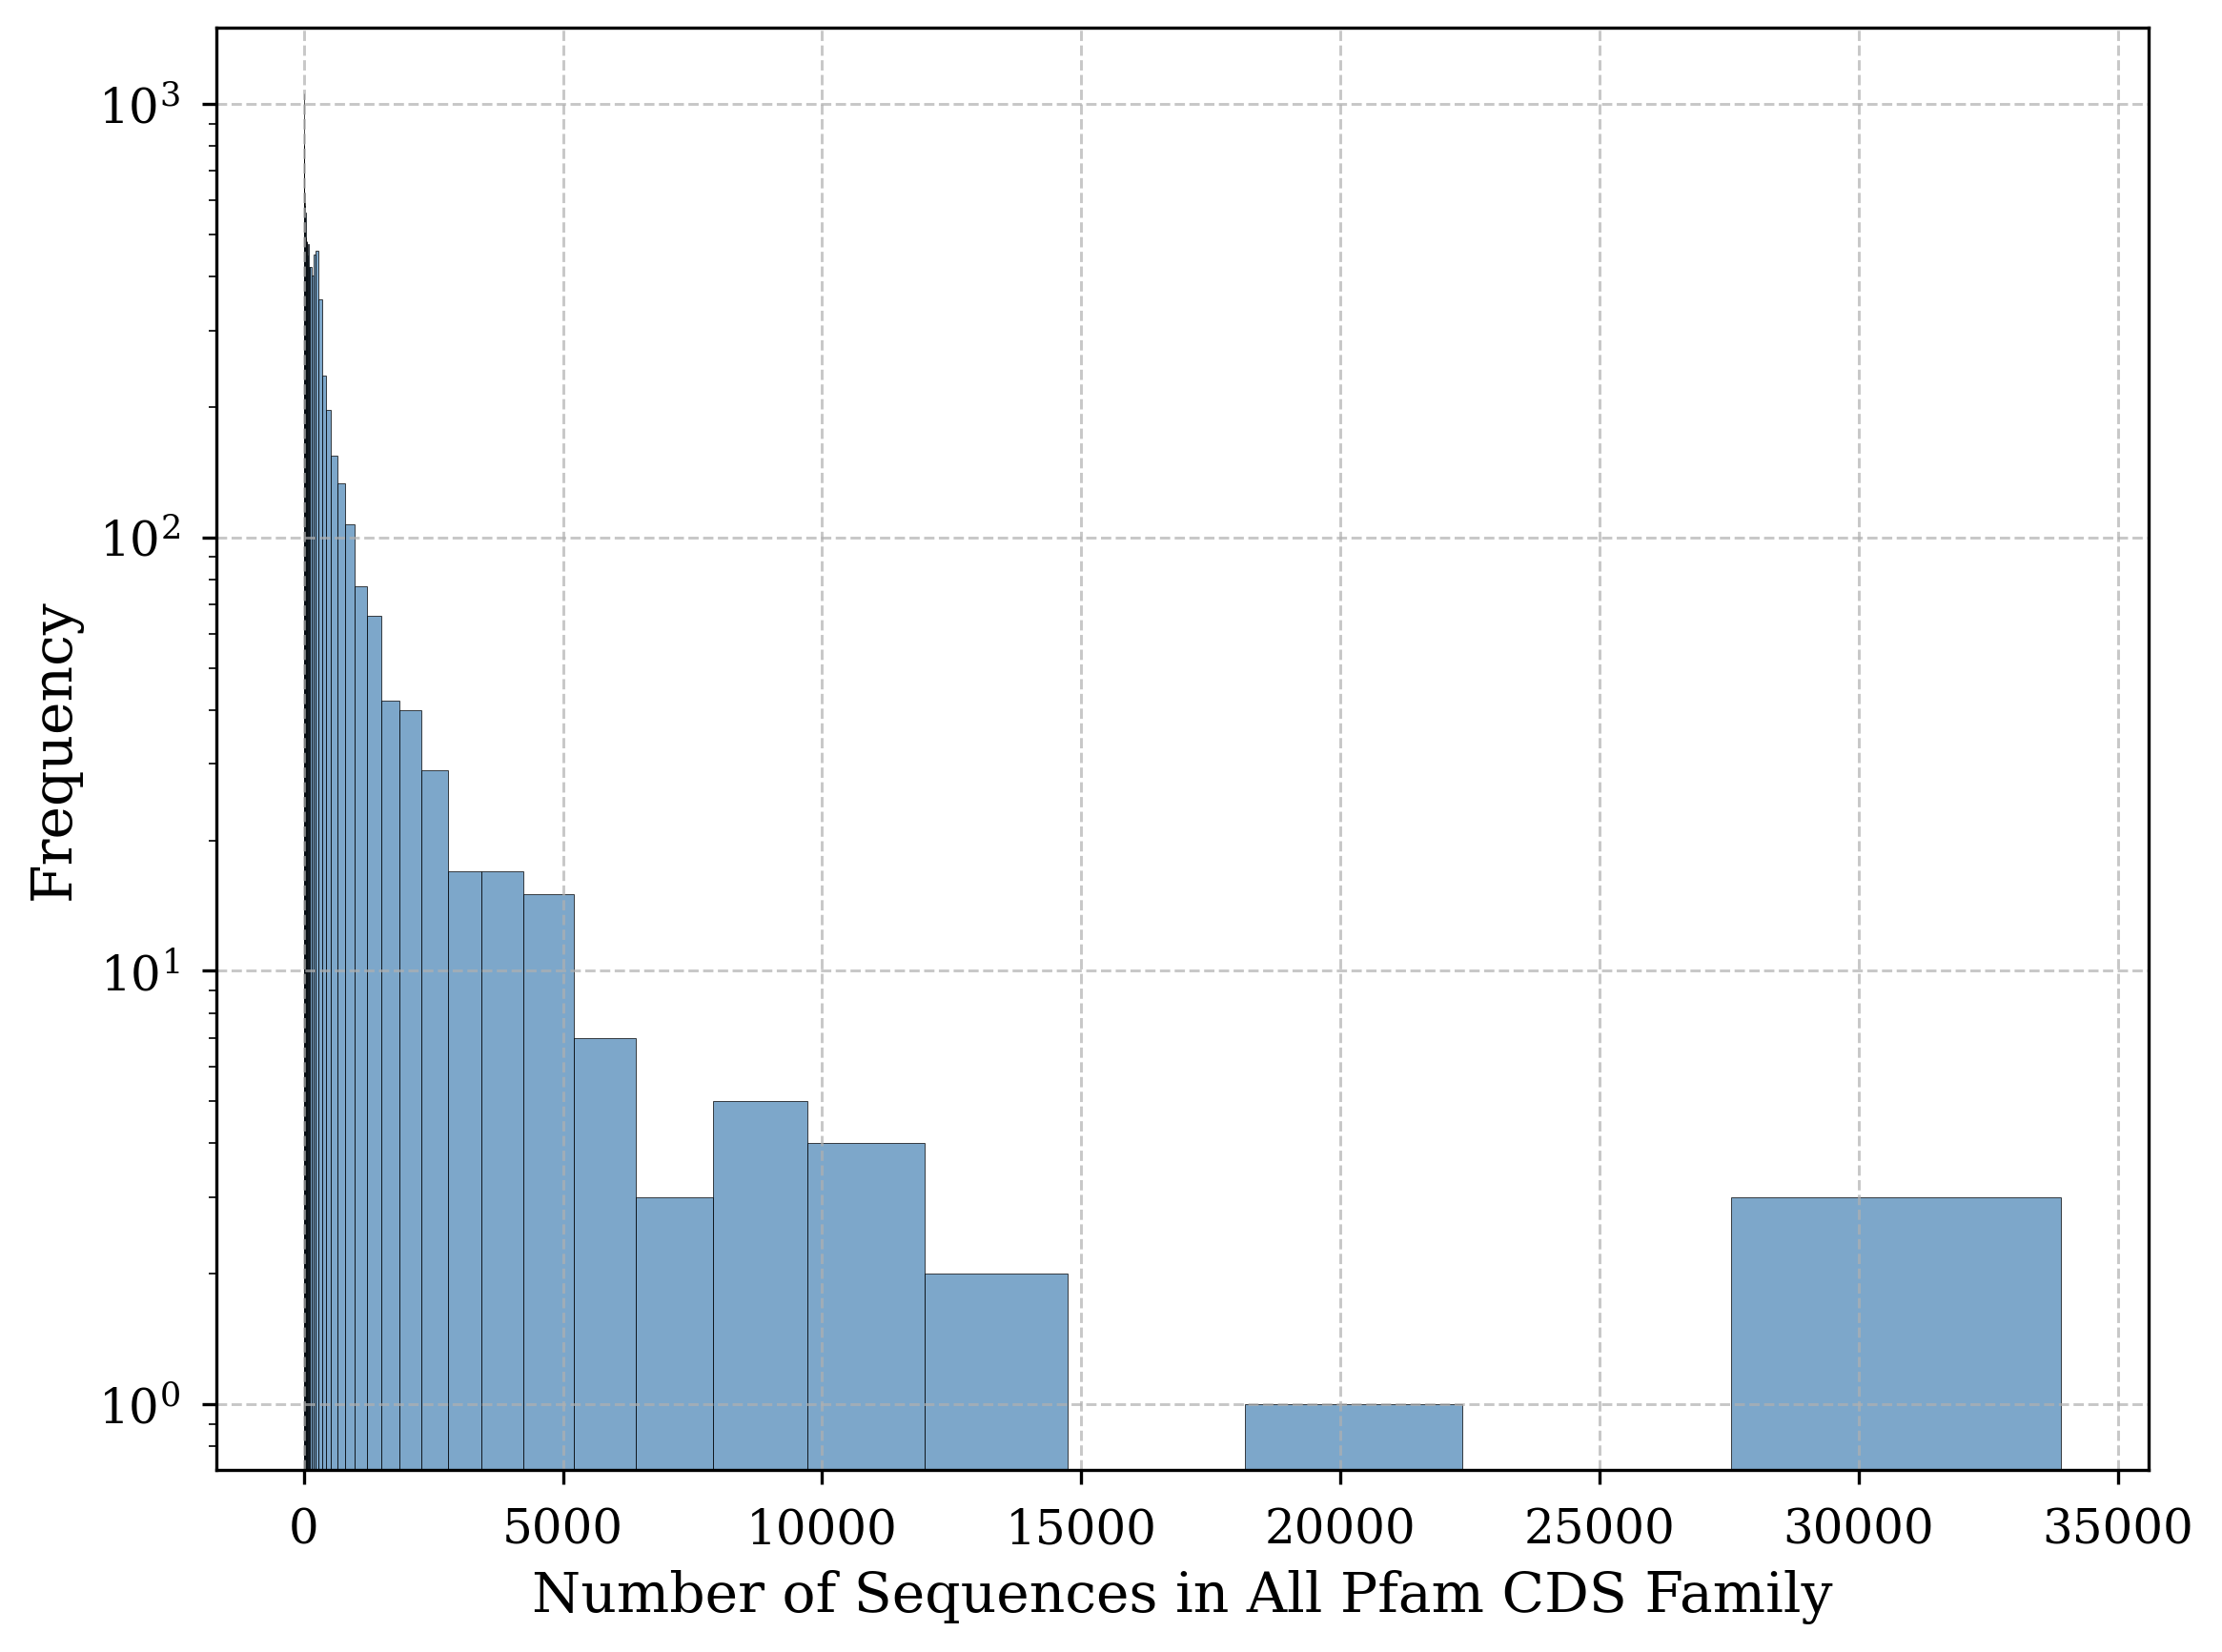

In [69]:
plot_histogram(sequences_per_family, xlabel="Number of Sequences in All Pfam CDS Family")

In [70]:
sequences_per_family.count(0) / len(sequences_per_family) # percent of families with representatives

0.2750743877317464

In [71]:
sequences_per_family.count(0) # number of families with representatives

6009